# Vector Data Cubes for Glacial Lakes

This is a notebook to create a vector data cube (VDC) of the glacial lakes at the southern margin of the Vatnajökull ice cap in southeast Iceland from 1985 to 2025 based on [original computational notebook](https://github.com/loreabad6/vdc-space-time-feats/blob/main/notebook/vdc-showcase.md) by Abad et al 2024.

**Input data:** `../OBIA_lake_outlines/glacial_lakes_<YYYY>.gpkg`  
**Fields per file:** `id`, `area_m2`, `year`, `geometry`  
**Temporal resolution:** one file per year, multiple polygons per file (one row per lake).

The difference from the lava-flow VDC is that **each lake is a separate feature** tracked across years,  
so the `geom_sum` dimension has one entry per lake (identified by `id`), not just one entry for a single feature.


In [1]:
from pathlib import Path
import numpy as np
import xvec
import os
import pandas as pd
import geopandas as gpd
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.patches import Patch
from matplotlib.cm import ScalarMappable
from shapely.ops import unary_union
from shapely import to_wkt
from shapely.affinity import affine_transform
import matplotlib.cm as cm
from shapely.geometry import Point, box
import re
import rioxarray
from config import OUT_DIR, DATA_DIR, OBIA_DIR

print("All libraries loaded successfully.")

All libraries loaded successfully.


## 1. Data loading and pre-processing

### 1.1 Read all annual GeoPackages

Each file is named `glacial_lakes_<YYYY>.gpkg`.  
We extract the year from the filename and store it as an integer column `year`.

In [2]:
# Find all annual files and sort chronologically
gpkg_files = sorted(OBIA_DIR.glob("glacial_lakes_*.gpkg"))
print(f"Found {len(gpkg_files)} files:")
for f in gpkg_files:
    print(f"  {f.name}")

Found 39 files:
  glacial_lakes_1985.gpkg
  glacial_lakes_1986.gpkg
  glacial_lakes_1987.gpkg
  glacial_lakes_1988.gpkg
  glacial_lakes_1989.gpkg
  glacial_lakes_1990.gpkg
  glacial_lakes_1991.gpkg
  glacial_lakes_1992.gpkg
  glacial_lakes_1993.gpkg
  glacial_lakes_1994.gpkg
  glacial_lakes_1995.gpkg
  glacial_lakes_1996.gpkg
  glacial_lakes_1997.gpkg
  glacial_lakes_1998.gpkg
  glacial_lakes_1999.gpkg
  glacial_lakes_2000.gpkg
  glacial_lakes_2001.gpkg
  glacial_lakes_2002.gpkg
  glacial_lakes_2004.gpkg
  glacial_lakes_2005.gpkg
  glacial_lakes_2006.gpkg
  glacial_lakes_2007.gpkg
  glacial_lakes_2010.gpkg
  glacial_lakes_2011.gpkg
  glacial_lakes_2012.gpkg
  glacial_lakes_2013.gpkg
  glacial_lakes_2014.gpkg
  glacial_lakes_2015.gpkg
  glacial_lakes_2016.gpkg
  glacial_lakes_2017.gpkg
  glacial_lakes_2018.gpkg
  glacial_lakes_2019.gpkg
  glacial_lakes_2020.gpkg
  glacial_lakes_2021.gpkg
  glacial_lakes_2022.gpkg
  glacial_lakes_2023.gpkg
  glacial_lakes_2024.gpkg
  glacial_lakes_2025.g

In [3]:
#### THIS IS EXTRA FOR MANUAL OUTLINES ####
TARGET_CRS = "EPSG:32627"  # WGS 84 / UTM zone 32N — pick what fits your study area

def read_lake_file(path: Path, target_crs: str) -> gpd.GeoDataFrame:
    """
    Read a single annual glacial-lake GeoPackage.
    - Extracts year from filename
    - Reprojects to target CRS
    - Computes area_m2 in projected units
    """
    gdf = gpd.read_file(path)
    year_from_fn = int(path.stem.split("_")[-1])

    # Reproject to common CRS first
    if gdf.crs is None:
        raise ValueError(f"No CRS defined in {path.name} — set it manually before proceeding.")
    if gdf.crs.to_string() != target_crs:
        gdf = gdf.to_crs(target_crs)

    # Compute area in square metres (valid after UTM reprojection)
    gdf["area_m2"] = gdf.geometry.area
    gdf["year"] = year_from_fn
    gdf["source_file"] = path.name

    return gdf

In [4]:
gpkg_files = sorted(OBIA_DIR.glob("glacial_lakes_*.gpkg"))
print("CRS inventory:")
for f in gpkg_files:
    crs = gpd.read_file(f, rows=0).crs  # fast — reads no geometry
    print(f"  {f.name:35s}  {crs}")

CRS inventory:
  glacial_lakes_1985.gpkg              EPSG:32627
  glacial_lakes_1986.gpkg              EPSG:32627
  glacial_lakes_1987.gpkg              EPSG:32627
  glacial_lakes_1988.gpkg              EPSG:32627
  glacial_lakes_1989.gpkg              EPSG:32627
  glacial_lakes_1990.gpkg              EPSG:32627
  glacial_lakes_1991.gpkg              EPSG:32627
  glacial_lakes_1992.gpkg              EPSG:32627
  glacial_lakes_1993.gpkg              EPSG:32627
  glacial_lakes_1994.gpkg              EPSG:32627
  glacial_lakes_1995.gpkg              EPSG:32627
  glacial_lakes_1996.gpkg              EPSG:32627
  glacial_lakes_1997.gpkg              EPSG:32627
  glacial_lakes_1998.gpkg              EPSG:32627
  glacial_lakes_1999.gpkg              EPSG:32627
  glacial_lakes_2000.gpkg              EPSG:32627
  glacial_lakes_2001.gpkg              EPSG:32627
  glacial_lakes_2002.gpkg              EPSG:32627
  glacial_lakes_2004.gpkg              EPSG:32627
  glacial_lakes_2005.gpkg          

In [5]:
all_lakes = pd.concat(
    [read_lake_file(p, TARGET_CRS) for p in gpkg_files],
    ignore_index=True
)
all_lakes = gpd.GeoDataFrame(all_lakes, geometry="geometry", crs=TARGET_CRS)

print(all_lakes.info())
print(f"\nYears present: {sorted(all_lakes['year'].unique())}")
print(f"CRS: {all_lakes.crs}")
print(f"area_m2 sample:\n{all_lakes['area_m2'].describe()}")


#### END OF EXTRA FOR MANUAL OUTLINES ####

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 198 entries, 0 to 197
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   area_m2      198 non-null    float64 
 1   year         198 non-null    int64   
 2   geometry     198 non-null    geometry
 3   source_file  198 non-null    str     
dtypes: float64(1), geometry(1), int64(1), str(1)
memory usage: 10.8 KB
None

Years present: [np.int64(1985), np.int64(1986), np.int64(1987), np.int64(1988), np.int64(1989), np.int64(1990), np.int64(1991), np.int64(1992), np.int64(1993), np.int64(1994), np.int64(1995), np.int64(1996), np.int64(1997), np.int64(1998), np.int64(1999), np.int64(2000), np.int64(2001), np.int64(2002), np.int64(2004), np.int64(2005), np.int64(2006), np.int64(2007), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64

In [6]:
# def read_lake_file(path: Path) -> gpd.GeoDataFrame:
#     """
#     Read a single annual glacial-lake GeoPackage.

#     The year is extracted from the filename (glacial_lakes_YYYY.gpkg) and stored as an integer in the column `year`.
#     Expected attribute fields: id, area_m2, year, geometry.
#     """
#     gdf = gpd.read_file(path)
#     # Extract year from filename as integer
#     year_from_fn = int(path.stem.split("_")[-1])  # e.g. 'glacial_lakes_2016' -> 2016
#     gdf["year"] = year_from_fn
#     gdf["source_file"] = path.name
#     return gdf



# # Read and concatenate all files
# all_lakes = pd.concat([read_lake_file(p) for p in gpkg_files], ignore_index=True)
# all_lakes = gpd.GeoDataFrame(all_lakes, geometry="geometry")

# print(all_lakes.info())
# print(f"\nYears present: {sorted(all_lakes['year'].unique())}")

In [7]:
print(all_lakes.groupby("year").size())
print(all_lakes.head(20)[["year", "area_m2", "geometry"]])

year
1985    5
1986    6
1987    3
1988    9
1989    4
1990    3
1991    4
1992    3
1993    3
1994    5
1995    6
1996    5
1997    5
1998    5
1999    5
2000    6
2001    6
2002    4
2004    5
2005    6
2006    4
2007    7
2010    6
2011    3
2012    6
2013    5
2014    5
2015    7
2016    6
2017    5
2018    5
2019    5
2020    5
2021    5
2022    4
2023    6
2024    6
2025    5
2026    5
dtype: int64
    year    area_m2                                           geometry
0   1985   947700.0  POLYGON ((735450 7117050, 735450 7116870, 7354...
1   1985   611100.0  POLYGON ((737100 7116540, 737100 7116510, 7370...
2   1985  9367200.0  POLYGON ((734040 7114620, 734040 7114560, 7340...
3   1985  5228100.0  POLYGON ((726090 7112670, 726090 7112640, 7260...
4   1985   494100.0  POLYGON ((725730 7107900, 725730 7107870, 7257...
5   1986   405000.0  POLYGON ((735840 7119330, 735840 7119300, 7357...
6   1986  2501100.0  POLYGON ((736080 7117830, 736080 7117800, 7360...
7   1986   450000.0  POL

### 1.2 Check CRS and reproject if needed

All files should share the same CRS. We reproject everything to a consistent projected CRS for metric calculations.

In [8]:
print(f"Native CRS: {all_lakes.crs}")

# Set target CRS 
TARGET_CRS = all_lakes.crs 

if all_lakes.crs is None:
    raise ValueError("CRS is missing. Set it explicitly: all_lakes = all_lakes.set_crs(<EPSG>)")

all_lakes = all_lakes.to_crs(TARGET_CRS)
print(f"Working CRS: {all_lakes.crs}")

Native CRS: EPSG:32627
Working CRS: EPSG:32627


### 1.3 Validate and fix geometries

In [9]:
invalid = (~all_lakes.geometry.is_valid).sum()
print(f"Invalid geometries before fix: {invalid}")
all_lakes["geometry"] = all_lakes["geometry"].make_valid()
all_lakes_raw = all_lakes.copy()
print(f"Invalid geometries after fix:  {(~all_lakes.geometry.is_valid).sum()}")

Invalid geometries before fix: 0
Invalid geometries after fix:  0


### 1.4 Explore grouping methods
Here we represent five different feature grouping methods:
1. Spatial overlap or proximity to threshold
2. Centroid of temporal union
3. Bounding box of temporal union
4. Automatic representative point
5. Manual representative point

#### 1.4.1. Spatial overlap or proximity to threshold
Assign ID for each lake based on spatial overlap or proximity over the years. First year each lake gets an ID. Lakes in the following years are matched to the nearest lake from the previous years if within threshold. If lake is outside threshold, the lake gets a new ID. We adjust the threshold based on visual evaluation.

In [10]:
def assign_lake_ids_prox(all_lakes: gpd.GeoDataFrame, distance_threshold_m: float = None) -> gpd.GeoDataFrame:
    """
    Assign consistent lake IDs across years based on spatial overlap or proximity.
    Lakes in the first year get IDs 1, 2, 3...
    Each subsequent year, a polygon is matched to the nearest prior-year lake if within distance_threshold_m; otherwise it gets a new ID.
    """
    years = sorted(all_lakes["year"].unique())
    all_lakes = all_lakes.copy()
    all_lakes["id"] = -1  # placeholder

    next_id = 1

    # Assign IDs to the first year
    first_year_mask = all_lakes["year"] == years[0]
    n_first = first_year_mask.sum()
    all_lakes.loc[first_year_mask, "id"] = range(next_id, next_id + n_first)
    next_id += n_first

    # For each subsequent year, match to previous year by overlap then proximity
    for yr in years[1:]:
        curr_mask = all_lakes["year"] == yr
        curr_idx = all_lakes[curr_mask].index

        # All lakes assigned so far (previous years)
        prev = all_lakes[all_lakes["id"] != -1].copy()

        for i in curr_idx:
            geom = all_lakes.at[i, "geometry"]

            # 1. Overlap with prior polygons
            overlapping = prev[prev.intersects(geom)]
            if not overlapping.empty:
                # Pick the one with the largest intersection area
                best_id = overlapping.copy()
                best_id["overlap"] = overlapping.geometry.intersection(geom).area
                assigned_id = best_id.loc[best_id["overlap"].idxmax(), "id"]
            else:
                # 2. Fall back to nearest within threshold
                distances = prev.geometry.distance(geom)
                min_dist = distances.min()
                if min_dist <= distance_threshold_m:
                    assigned_id = prev.loc[distances.idxmin(), "id"]
                else:
                    # 3. New lake, assign a new ID
                    assigned_id = next_id
                    next_id += 1

            all_lakes.at[i, "id"] = int(assigned_id)

    return all_lakes


all_lakes_prox = assign_lake_ids_prox(all_lakes_raw, distance_threshold_m=100)

print(f"Unique IDs assigned: {sorted(all_lakes_prox['id'].unique())}")

Unique IDs assigned: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]


Plot the result for visual inspection.

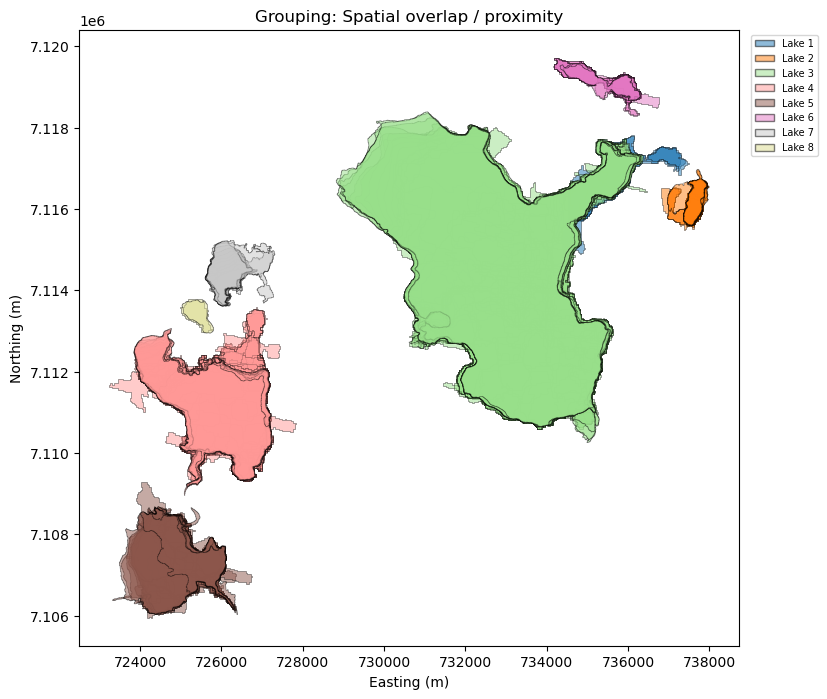

In [11]:
fig, ax = plt.subplots(figsize=(10, 8))
lake_ids_all = sorted(all_lakes_prox["id"].unique())
cmap = plt.cm.tab20
norm = mcolors.Normalize(vmin=0, vmax=len(lake_ids_all))
for j, lid in enumerate(lake_ids_all):
    all_lakes_prox[all_lakes_prox["id"] == lid].plot(ax=ax, color=cmap(norm(j)), alpha=0.5, edgecolor="k", linewidth=0.5)
legend_handles = [
    Patch(facecolor=cmap(norm(j)), edgecolor="k", alpha=0.5, label=f"Lake {lid}")
    for j, lid in enumerate(lake_ids_all)
]
ax.legend(handles=legend_handles, bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=7)
ax.set_title("Grouping: Spatial overlap / proximity")
ax.set_xlabel("Easting (m)")
ax.set_ylabel("Northing (m)")
id_overlap = os.path.join(OUT_DIR, f"lake_ids_overlap.png")
plt.savefig(id_overlap, bbox_inches='tight', dpi=150)
plt.show()
plt.close()

This approach seems to work well with a distance threshold of 200 m for this study area. All seven lakes have individual IDs, and the Jökulsárlón arm (1) that used to be its own lake also has its own ID before the merge. One thing to consider here; should the merged lakes have a new ID, instead of continuing with Jökulsárlóns ID? Likely not, as before the merge, the main lake was Jokulsarlon, and now it just has a larger extent.

**This method was selected** for Step 3 (Compute summary geometries) as it most accurately reflected reality among all tested approaches. However, it may not be universally applicable. A complicating factor in this dataset is the temporal inconsistency of the lake outlines as lakes that merged in a given year occasionally reappear as separate polygons in later years. In such cases this method still correctly groups them under the same ID, since their outlines overlap with the previously merged union. However, this also means that lakes which actually split over time would incorrectly retain the same shared ID, as the temporal overlap would prevent them from being distinguished as separate features.

#### 1.4.2. Centroid of temporal union
Assign an ID based on distance to the centroid of `unary_union` of all prior polygons in a group

In [30]:
def assign_lake_ids_centroid(all_lakes: gpd.GeoDataFrame, distance_threshold_m: float = None) -> gpd.GeoDataFrame:
    """
    Group polygons across years by proximity to the centroid of the running
    temporal union of each group so far.
    """
    years = sorted(all_lakes["year"].unique())
    all_lakes = all_lakes.copy()
    all_lakes["id"] = -1

    next_id = 1
    # running union per group: {id: Shapely geometry}
    group_union = {}

    # Seed first year
    first_mask = all_lakes["year"] == years[0]
    for i in all_lakes[first_mask].index:
        all_lakes.at[i, "id"] = next_id
        group_union[next_id] = all_lakes.at[i, "geometry"]
        next_id += 1

    for yr in years[1:]:
        curr_idx = all_lakes[all_lakes["year"] == yr].index

        # Build a GeoSeries of group centroids for fast distance query
        group_ids = list(group_union.keys())
        centroids = gpd.GeoSeries(
            [group_union[gid].centroid for gid in group_ids],
            index=group_ids,
            crs=all_lakes.crs,
        )

        for i in curr_idx:
            geom = all_lakes.at[i, "geometry"]
            # 1. Find the nearest group centroid
            distances = centroids.distance(geom.centroid)
            min_dist = distances.min()
            if min_dist <= distance_threshold_m:
                assigned_id = distances.idxmin()
            else:
                # 2. New lake, assign a new ID
                assigned_id = next_id
                next_id += 1

            all_lakes.at[i, "id"] = int(assigned_id)
            # Update the running union
            if assigned_id in group_union:
                group_union[assigned_id] = group_union[assigned_id].union(geom)
            else:
                group_union[assigned_id] = geom

    return all_lakes


all_lakes_centroid = assign_lake_ids_centroid(all_lakes_raw, distance_threshold_m=2500)

print(f"Unique IDs assigned: {sorted(all_lakes_centroid['id'].unique())}")

Unique IDs assigned: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]


Plot the outlines and the centroid of the temporal union of each lake for visual inspection. Note that the plotted centroid is of the most recent extent, and it evolves through the years.

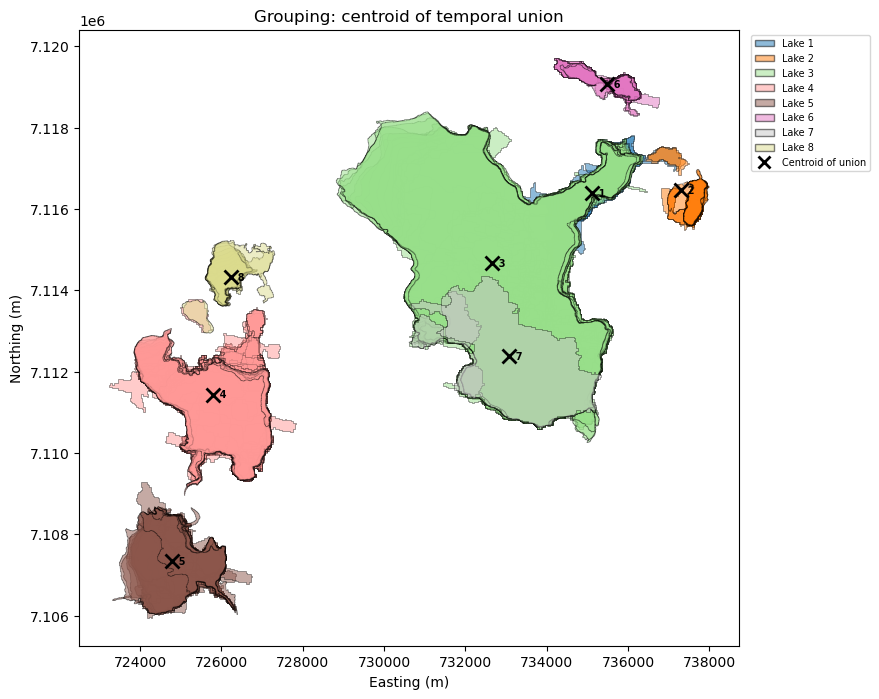

In [31]:
fig, ax = plt.subplots(figsize=(10, 8))
lake_ids_all = sorted(all_lakes_centroid["id"].unique())
cmap = plt.cm.tab20
norm = mcolors.Normalize(vmin=0, vmax=len(lake_ids_all))

# Compute the centroid of the temporal union per lake (the actual reference geometry used during grouping)
group_centroids = (
    all_lakes_centroid.dropna(subset=["geometry"])
    .groupby("id")["geometry"]
    .apply(lambda g: unary_union(g).centroid)
)

for j, lid in enumerate(lake_ids_all):
    subset = all_lakes_centroid[all_lakes_centroid["id"] == lid]
    subset.plot(ax=ax, color=cmap(norm(j)), alpha=0.5, edgecolor="k", linewidth=0.5)

# Overlay centroids
for j, lid in enumerate(lake_ids_all):
    pt = group_centroids[lid]
    ax.plot(pt.x, pt.y, marker="x", markersize=10, markeredgewidth=2,
            color="black", zorder=5)
    ax.annotate(f"  {lid}", (pt.x, pt.y), fontsize=7, va="center",
                color="black", fontweight="bold")

legend_handles = [
    Patch(facecolor=cmap(norm(j)), edgecolor="k", alpha=0.5, label=f"Lake {lid}")
    for j, lid in enumerate(lake_ids_all)
]
legend_handles.append(
    plt.Line2D([0], [0], marker="x", color="black", linestyle="None",
               markersize=8, markeredgewidth=2, label="Centroid of union")
)
ax.legend(handles=legend_handles, bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=7)
ax.set_title("Grouping: centroid of temporal union")
ax.set_xlabel("Easting (m)")
ax.set_ylabel("Northing (m)")
id_centroid = os.path.join(OUT_DIR, f"lake_ids_centroid.png")
plt.savefig(id_centroid, bbox_inches='tight', dpi=150)
plt.show()
plt.close()

This approach faces challenges with inconsistent lake outlines and lakes with close proximity. The centroid of the temporal union is the average of all coordinates weighted by area of the previous years. As the lake outlines are not accurate, some inconsistent outlines had a centroid too far from the previous years centroid and were assigned a new ID. The distance threshold was set higher (2.5 km) to reduce the number of IDs assigned for Jökulsárlón (3), but still one "extra" ID (7) remains. The higher threshold starts to mix up nearby lakes such as the unnamed small lake (8) with Breiðárlón (4) and the water body between Jökulsárlón arm (1) and Stemmulón (2). 

This method would benefit from spatially consistent outlines, as then the threshold could be set lower, preventing the mixing between lakes and facilitating the splitting problem compared to the previous spatial overlap method.

#### 1.4.3. Bounding box of temporal union
Assign IDs based on intersection or distance to the bbox of `unary_union` of all prior polygons.

In [32]:
def assign_lake_ids_bbox(all_lakes: gpd.GeoDataFrame, distance_threshold_m: float = None) -> gpd.GeoDataFrame:
    """
    Group polygons across years using the bounding box (envelope) of the running
    temporal union of each group as the reference geometry.
    A new polygon is assigned to a group if it intersects or is within
    distance_threshold_m of that group's bbox.
    """
    years = sorted(all_lakes["year"].unique())
    all_lakes = all_lakes.copy()
    all_lakes["id"] = -1

    next_id = 1
    group_union = {}

    first_mask = all_lakes["year"] == years[0]
    for i in all_lakes[first_mask].index:
        all_lakes.at[i, "id"] = next_id
        group_union[next_id] = all_lakes.at[i, "geometry"]
        next_id += 1

    for yr in years[1:]:
        curr_idx = all_lakes[all_lakes["year"] == yr].index

        group_ids = list(group_union.keys())
        bboxes = gpd.GeoSeries(
            [group_union[gid].envelope for gid in group_ids],
            index=group_ids,
            crs=all_lakes.crs,
        )

        for i in curr_idx:
            geom = all_lakes.at[i, "geometry"]

            # 1. Overlap with any bbox
            overlapping = bboxes[bboxes.intersects(geom)]
            if not overlapping.empty:
                # pick bbox with largest intersection area
                best = overlapping.copy().to_frame("bbox_geom")
                best["overlap"] = overlapping.intersection(geom).area
                assigned_id = best["overlap"].idxmax()
            else:
                # 2. Fall back to nearest within threshold
                distances = bboxes.distance(geom)
                min_dist = distances.min()
                if min_dist <= distance_threshold_m:
                    assigned_id = distances.idxmin()
                else:
                    # 3. New lake, assign a new ID
                    assigned_id = next_id
                    next_id += 1

            all_lakes.at[i, "id"] = int(assigned_id)
            if assigned_id in group_union:
                group_union[assigned_id] = group_union[assigned_id].union(geom)
            else:
                group_union[assigned_id] = geom

    return all_lakes


all_lakes_bbox = assign_lake_ids_bbox(all_lakes_raw, distance_threshold_m=1)

print(f"Unique IDs assigned: {sorted(all_lakes_bbox['id'].unique())}")

Unique IDs assigned: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7)]


Plot the outlines and the bounding boxes of the temporal union per lake. Note that bounding box is created for the most recent extent, and the box evolves through the years.

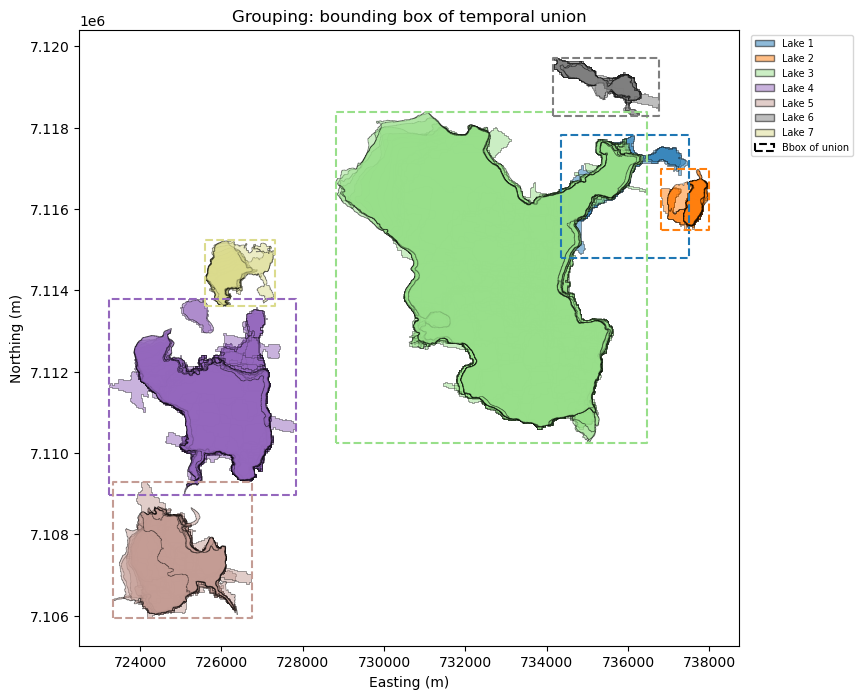

In [33]:
fig, ax = plt.subplots(figsize=(10, 8))
lake_ids_all = sorted(all_lakes_bbox["id"].unique())
cmap = plt.cm.tab20
norm = mcolors.Normalize(vmin=0, vmax=len(lake_ids_all))

# Compute the bounding box of the temporal union per lake
group_bboxes = (
    all_lakes_bbox.dropna(subset=["geometry"])
    .groupby("id")["geometry"]
    .apply(lambda g: unary_union(g).envelope)
)
group_bboxes = gpd.GeoSeries(group_bboxes, crs=all_lakes_bbox.crs)

for j, lid in enumerate(lake_ids_all):
    subset = all_lakes_bbox[all_lakes_bbox["id"] == lid]
    subset.plot(ax=ax, color=cmap(norm(j)), alpha=0.5, edgecolor="k", linewidth=0.5)

# Overlay bounding boxes as outlines only 
for j, lid in enumerate(lake_ids_all):
    gpd.GeoSeries([group_bboxes[lid]]).plot(
        ax=ax, facecolor="none", edgecolor=cmap(norm(j)),
        linewidth=1.5, linestyle="--", zorder=5
    )

legend_handles = [
    Patch(facecolor=cmap(norm(j)), edgecolor="k", alpha=0.5, label=f"Lake {lid}")
    for j, lid in enumerate(lake_ids_all)
]
legend_handles.append(
    Patch(facecolor="none", edgecolor="k", linewidth=1.5,
          linestyle="--", label="Bbox of union")
)
ax.legend(handles=legend_handles, bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=7)
ax.set_title("Grouping: bounding box of temporal union")
ax.set_xlabel("Easting (m)")
ax.set_ylabel("Northing (m)")
id_bbox = os.path.join(OUT_DIR, f"lake_ids_bbox.png")
plt.savefig(id_bbox, bbox_inches='tight', dpi=150)
plt.show()
plt.close()

This approach has difficulty classifying lakes that are spatially nested within another lake. As Breiðárlón (4) curves inward on the northern side, its bounding box encloses a smaller neighbouring lake, causing it to be misclassified even at a distance threshold of 10 m.

#### 1.4.4. Representative point
Assign IDs based on distance to `representative_point()` by `shapely` of `unary_union` of all prior polygons.

In [34]:
def assign_lake_ids_repr_point(all_lakes: gpd.GeoDataFrame, distance_threshold_m: float = None) -> gpd.GeoDataFrame:
    """
    Group polygons using the representative_point() of the running temporal union.
    Unlike centroid, representative_point() always lies inside the polygon,
    making it more robust for concave or fragmented shapes.
    """
    years = sorted(all_lakes["year"].unique())
    all_lakes = all_lakes.copy()
    all_lakes["id"] = -1

    next_id = 1
    group_union = {}

    first_mask = all_lakes["year"] == years[0]
    for i in all_lakes[first_mask].index:
        all_lakes.at[i, "id"] = next_id
        group_union[next_id] = all_lakes.at[i, "geometry"]
        next_id += 1

    for yr in years[1:]:
        curr_idx = all_lakes[all_lakes["year"] == yr].index

        group_ids = list(group_union.keys())
        repr_pts = gpd.GeoSeries(
            [group_union[gid].representative_point() for gid in group_ids],
            index=group_ids,
            crs=all_lakes.crs,
        )

        for i in curr_idx:
            # 1. Find the nearest group representative point
            geom = all_lakes.at[i, "geometry"]
            distances = repr_pts.distance(geom.centroid)
            min_dist = distances.min()
            if min_dist <= distance_threshold_m:
                assigned_id = distances.idxmin()
            else:
                # 2. New lake, assign a new ID
                assigned_id = next_id
                next_id += 1

            all_lakes.at[i, "id"] = int(assigned_id)
            if assigned_id in group_union:
                group_union[assigned_id] = group_union[assigned_id].union(geom)
            else:
                group_union[assigned_id] = geom

    return all_lakes


all_lakes_repr = assign_lake_ids_repr_point(all_lakes_raw, distance_threshold_m=2500)

print(f"Unique IDs assigned: {sorted(all_lakes_repr['id'].unique())}")

Unique IDs assigned: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9)]


Plot the grouped lake outlines with their automatically computed representative points.

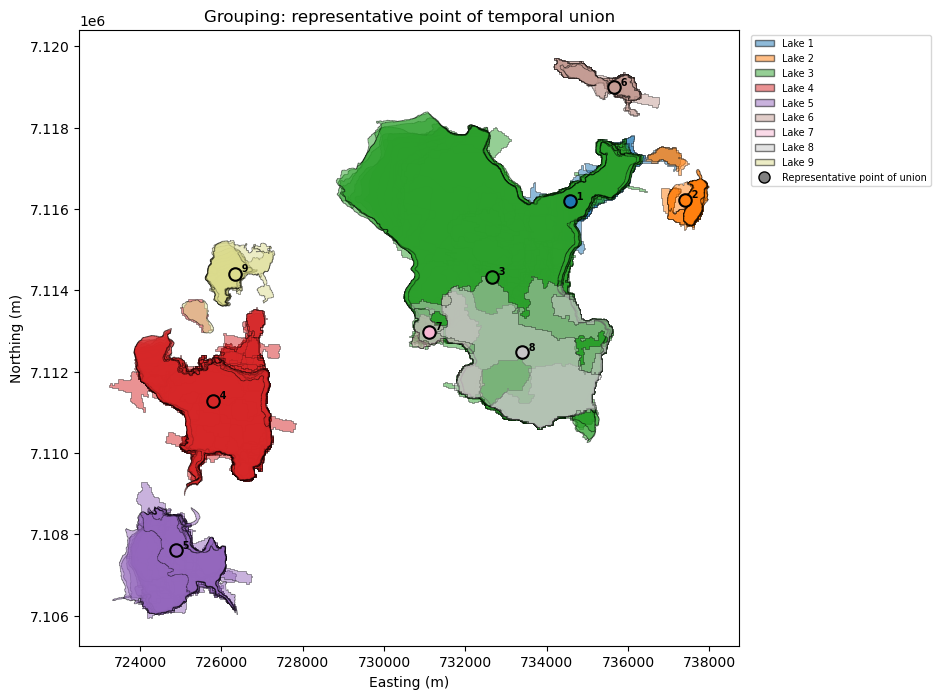

In [35]:
fig, ax = plt.subplots(figsize=(10, 8))
lake_ids_all = sorted(all_lakes_repr["id"].unique())
cmap = plt.cm.tab20
norm = mcolors.Normalize(vmin=0, vmax=len(lake_ids_all))

# Compute the representative point of the temporal union per lake
group_repr_pts = (
    all_lakes_repr.dropna(subset=["geometry"])
    .groupby("id")["geometry"]
    .apply(lambda g: unary_union(g).representative_point())
)

for j, lid in enumerate(lake_ids_all):
    subset = all_lakes_repr[all_lakes_repr["id"] == lid]
    subset.plot(ax=ax, color=cmap(norm(j)), alpha=0.5, edgecolor="k", linewidth=0.5)

# Overlay representative points 
for j, lid in enumerate(lake_ids_all):
    pt = group_repr_pts[lid]
    ax.plot(pt.x, pt.y, marker="o", markersize=9, markeredgewidth=1.5,
            markerfacecolor=cmap(norm(j)), markeredgecolor="k", zorder=5)
    ax.annotate(f"  {lid}", (pt.x, pt.y), fontsize=7, va="bottom",
                color="black", fontweight="bold")

legend_handles = [
    Patch(facecolor=cmap(norm(j)), edgecolor="k", alpha=0.5, label=f"Lake {lid}")
    for j, lid in enumerate(lake_ids_all)
]
legend_handles.append(
    plt.Line2D([0], [0], marker="o", color="k", linestyle="None",
               markersize=8, markerfacecolor="gray", markeredgecolor="k",
               label="Representative point of union")
)
ax.legend(handles=legend_handles, bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=7)
ax.set_title("Grouping: representative point of temporal union")
ax.set_xlabel("Easting (m)")
ax.set_ylabel("Northing (m)")
id_repr = os.path.join(OUT_DIR, f"lake_ids_repr.png")
plt.savefig(id_repr, bbox_inches='tight', dpi=150)
plt.show()
plt.close()

This approach is very similar to the centroid method. The difference is that while the centroid of the temporal union can fall outside the polygon for irregular or concave shapes, the representative point is guaranteed to be inside it. This is because `shapely`s `representative_point()` chooses the midpoint of the longest east-west line inside the polygon, rather than the geometric centre of mass. However, with the same distance threshold (2.5 km), representative point method has the same difficulties with nearby lakes as centroid (lakes 4 and 9, and lakes 1 and 2), with an additional ID (7) within Jökulsárlón.

#### 1.4.5. Manual representative point

As `shapely`s `representative_point()` had difficulty locating points that actually represent the lakes the best, we also assign IDs based on manually chosen representative points of `unary_union` of all prior polygons.

The representative points were placed in areas of maximum temporal overlap, meaning locations that fall within the lake outline in as many years as possible for each individual lake.

In [36]:
repr_pts_manual = gpd.read_file(os.path.join(DATA_DIR, "representative_points.gpkg"))
repr_pts_manual = repr_pts_manual.to_crs(all_lakes_raw.crs)

repr_pts_manual

,lake_id,geometry
0,3,POINT (734291.525 7111379.698)
1,4,POINT (726389.482 7111125.885)
2,5,POINT (725729.568 7107335.612)
3,2,POINT (737641.856 7115931.41)
4,6,POINT (735459.065 7119180.216)
5,7,POINT (726221.994 7114335.38)
6,8,POINT (725411.039 7113441.251)
7,1,POINT (735002.201 7116354.432)


In [37]:
def assign_lake_ids_manual_repr(all_lakes: gpd.GeoDataFrame, repr_points: gpd.GeoDataFrame, distance_threshold_m: float = None, point_id_col: str = "lake_id",) -> gpd.GeoDataFrame:
    """
    Assign lake IDs based on proximity to manually defined representative points of the temporal union.
    Each point in repr_points represents one lake group.
    A polygon is assigned to the nearest point within distance_threshold_m.
    If no point is within threshold, the polygon gets a new ID.
    """
    years = sorted(all_lakes["year"].unique())
    all_lakes = all_lakes.copy()
    all_lakes["id"] = -1


    next_new_id = max(repr_points[point_id_col]) + 1
    
    # Initialise the running union from the manual points (as tiny buffers,
    # so unary_union has a real geometry to work with from the start)
    group_union = {
        row[point_id_col]: row["geometry"].buffer(1)
        for _, row in repr_points.iterrows()
    }

    for yr in years:
        curr_idx = all_lakes[all_lakes["year"] == yr].index

        group_ids = list(group_union.keys())
        repr_pts_running = gpd.GeoSeries(
            [group_union[gid].representative_point() for gid in group_ids],
            index=group_ids,
            crs=all_lakes.crs,
        )

        for i in curr_idx:
            # 1. Find the nearest group representative point
            geom = all_lakes.at[i, "geometry"]
            if geom is None or geom.is_empty:
                continue
            distances = repr_pts_running.distance(geom.centroid)
            min_dist = distances.min()
            if min_dist <= distance_threshold_m:
                assigned_id = distances.idxmin()
            else:
                # 2. New lake, assign a new ID
                assigned_id = next_new_id
                next_new_id += 1

            all_lakes.at[i, "id"] = int(assigned_id)
            if assigned_id in group_union:
                group_union[assigned_id] = group_union[assigned_id].union(geom)
            else:
                group_union[assigned_id] = geom

    return all_lakes


all_lakes_manual = assign_lake_ids_manual_repr(
    all_lakes_raw,
    repr_points=repr_pts_manual,
    distance_threshold_m=3000,
    point_id_col="lake_id",
)

print(f"Unique IDs assigned: {sorted(all_lakes_manual['id'].unique())}")

Unique IDs assigned: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]


Plot the grouped lake outlines with their manually selected representative points.

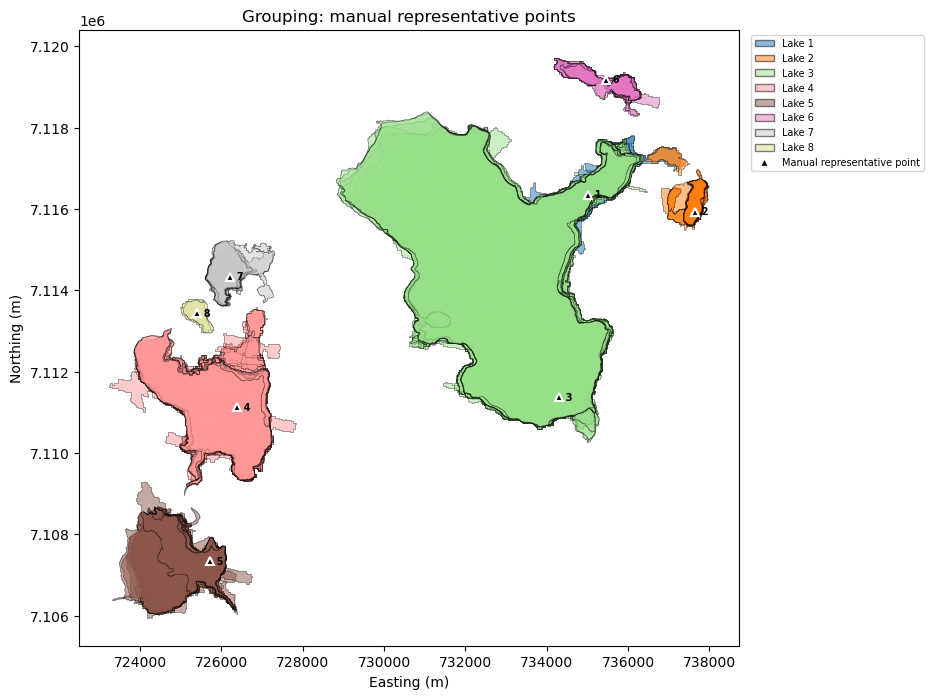

In [38]:
fig, ax = plt.subplots(figsize=(10, 8))
lake_ids_all = sorted(all_lakes_manual["id"].unique())
cmap = plt.cm.tab20
norm = mcolors.Normalize(vmin=0, vmax=len(lake_ids_all))

for j, lid in enumerate(lake_ids_all):
    subset = all_lakes_manual[all_lakes_manual["id"] == lid]
    subset.plot(ax=ax, color=cmap(norm(j)), alpha=0.5, edgecolor="k", linewidth=0.5)

# Overlay manual representative points
repr_pts_manual_proj = repr_pts_manual.set_index("lake_id")
for j, lid in enumerate(lake_ids_all):
    if lid not in repr_pts_manual_proj.index:
        continue  # skip outlier IDs that have no manual point
    pt = repr_pts_manual_proj.loc[lid, "geometry"]
    ax.plot(pt.x, pt.y, marker="^", markersize=6, markeredgewidth=1.5,
            markerfacecolor="black", markeredgecolor="white", zorder=5)
    ax.annotate(f"  {lid}", (pt.x, pt.y), fontsize=7, va="center",
                color="black", fontweight="bold")

legend_handles = [
    Patch(facecolor=cmap(norm(j)), edgecolor="k", alpha=0.5, label=f"Lake {lid}")
    for j, lid in enumerate(lake_ids_all)
]
legend_handles.append(
    plt.Line2D([0], [0], marker="^", color="black", linestyle="None",
               markersize=6, markerfacecolor="black", markeredgecolor="white",
               label="Manual representative point")
)
ax.legend(handles=legend_handles, bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=7)
ax.set_title("Grouping: manual representative points")
ax.set_xlabel("Easting (m)")
ax.set_ylabel("Northing (m)")
id_manual = os.path.join(OUT_DIR, f"lake_ids_manual_repr.png")
plt.savefig(id_manual, bbox_inches='tight', dpi=150)
plt.show()
plt.close()

This approach works well with individual lakes, but faces diffculty when two lakes have merged but outlines are inconstent. After the Jökulsárlón arm (1) merged with Jökulsárlón (3), the outlines were still in some years after separated and Jökulsárlón arm was again assigned with its own ID. A way to fix this could be to compare the overlap area between new polygon and each group's temporal union, and only fall back to distance when there is no overlap. We added the overlap aspect in the next section.

However, if the lake outlines would be accurate and consistent, this problem would not exist. In addition, if there are cases when lakes actually separate, this method would correctly identify them as separate lakes. Manually locating representative points works well with our small study area, but with cases with hundreds of lakes, manual work would be too inefficient.

### 1.5 Prepare per-lake, per-year geometry & check for missing (lake, year) combinations

Because each `.gpkg` can contain multiple polygons (one per lake), we now have a long-format GeoDataFrame
with one row per (`id`, `year`) combination.

If the same lake id appears more than once in a single year (e.g. fragmented polygons),
we union them into a single geometry per (`id`, `year`).

Not every lake may be present in every year. The VDC needs a fully populated grid,
so we identify gaps and fill them with `None` geometries.

In [39]:
def make_outlines(all_lakes_gdf: gpd.GeoDataFrame, crs) -> gpd.GeoDataFrame:
    """
    Union polygons with the same id within the same year,
    fill missing (id, year) combinations with None geometry,
    and return a clean sorted GeoDataFrame.
    """
    outlines = (
        all_lakes_gdf
        .groupby(["id", "year"], as_index=False)
        .agg(
            geometry=("geometry", lambda g: unary_union(g)),
            area_m2=("area_m2", "sum"),
        )
    )
    outlines = gpd.GeoDataFrame(outlines, geometry="geometry", crs=crs)
    outlines["geometry"] = outlines["geometry"].make_valid()

    # Fill missing (id, year) combinations
    lake_ids  = sorted(outlines["id"].unique())
    year_list = sorted(outlines["year"].unique())
    full_index    = pd.MultiIndex.from_product([lake_ids, year_list], names=["id", "year"])
    current_index = pd.MultiIndex.from_frame(outlines[["id", "year"]])
    missing = full_index.difference(current_index)

    if len(missing) > 0:
        fill_rows = pd.DataFrame(
            [{"id": i, "year": y, "geometry": None, "area_m2": np.nan} for i, y in missing]
        )
        fill_gdf = gpd.GeoDataFrame(fill_rows, geometry="geometry", crs=crs)
        outlines = pd.concat([outlines, fill_gdf], ignore_index=True)
        outlines = gpd.GeoDataFrame(outlines, geometry="geometry", crs=crs)
        outlines = outlines.sort_values(["id", "year"]).reset_index(drop=True)

    print(f"  {len(lake_ids)} lakes × {len(year_list)} years "
          f"({len(missing)} missing combinations filled)")
    return outlines

### 1.6 VDC creation

We create VDC using `xvec` package and add lake names as a data variable. These are done inside a function to create a VDC per grouping method.
We create a `xr.Dataset`structure (≈ a multi-variable cube).

In [40]:
lake_names = {
    1: "Jökulsárlón arm",
    2: "Stemmulón",  
    3: "Jökulsárlón",
    4: "Breiðárlón",
    5: "Fjallsárlón",
    6: "Veðurárlón",
    7: "Unnamed_1",
    8: "Unnamed_2",
}

def make_vdc(outlines: gpd.GeoDataFrame, crs, lake_names: dict = lake_names) -> xr.Dataset:
    """
    Convert a filled outlines GeoDataFrame to an xarray Dataset
    with CRS and lake_name coordinate attached.
    """
    ds = (
        outlines
        .set_index(["id", "year"])
        .to_xarray()
        .proj.assign_crs(spatial_ref=crs)
    )
    name_array = [lake_names.get(i, f"Lake_{i}") for i in ds["id"].values]
    ds = ds.assign_coords(lake_name=("id", name_array))
    return ds


def build_all_vdcs(
    grouped_gdfs: dict[str, gpd.GeoDataFrame],
    crs,
    lake_names: dict = lake_names,
) -> tuple[dict[str, xr.Dataset], dict[str, gpd.GeoDataFrame]]:
    """
    Run make_outlines + make_vdc for every grouping method.

    Parameters
    ----------
    grouped_gdfs : dict mapping method name -> all_lakes_* GeoDataFrame
                   (the raw output of assign_lake_ids_* before union/fill)
    crs          : the CRS to use (e.g. all_lakes.crs)
    lake_names   : dict mapping integer id -> lake name string

    Returns
    -------
    vdcs         : dict mapping method name -> xr.Dataset (the VDC)
    outlines_gdfs: dict mapping method name -> filled outlines GeoDataFrame
                   
    """
    vdcs          = {}
    outlines_gdfs = {}
    for name, gdf in grouped_gdfs.items():
        print(f"Building VDC: {name}")
        outlines          = make_outlines(gdf, crs)
        outlines_gdfs[name] = outlines
        vdcs[name]        = make_vdc(outlines, crs, lake_names)
    return vdcs, outlines_gdfs

In [41]:
grouped_gdfs = {
    "proximity":      all_lakes_prox,
    "centroid":       all_lakes_centroid,
    "bbox":           all_lakes_bbox,
    "repr_point":     all_lakes_repr,
    "manual":         all_lakes_manual,
}

vdcs, outlines_gdfs = build_all_vdcs(grouped_gdfs, crs=all_lakes.crs)

# Unpack individual VDCs for use in Section 3 (summary geometries)
outlines_ds_prox     = vdcs["proximity"]
outlines_ds_centroid = vdcs["centroid"]
outlines_ds_bbox     = vdcs["bbox"]
outlines_ds_repr     = vdcs["repr_point"]
outlines_ds_manual   = vdcs["manual"]

print("VDCs and outlines built for:", list(vdcs.keys()))


Building VDC: proximity
  8 lakes × 39 years (131 missing combinations filled)
Building VDC: centroid
  8 lakes × 39 years (126 missing combinations filled)
Building VDC: bbox
  7 lakes × 39 years (93 missing combinations filled)
Building VDC: repr_point
  9 lakes × 39 years (164 missing combinations filled)
Building VDC: manual
  8 lakes × 39 years (128 missing combinations filled)
VDCs and outlines built for: ['proximity', 'centroid', 'bbox', 'repr_point', 'manual']


## 2. Comparing grouping methods

### 2.1 Spatiotemporal dynamics analysis
Here we aim to quantify four types of spatiotemporal dynamics, **disappearing**, **reappearing**, **merging**, and **splitting**, and compare how each grouping method handles them.

#### 2.1.1 Disappearing and reappearing lakes

A lake disappears when its geometry is `None` for one or more consecutive years after first being observed.
It reappears if a non-`None` geometry follows a gap.

We use the filled `(id, year)` GeoDataFrames from `make_outlines()`, which already encode absences as `None` geometries.

In [42]:
def analyse_gaps(
    outlines_gdf: gpd.GeoDataFrame,
    min_gap_years: int = 4,
    min_trailing_gap_years: int = 3,
) -> pd.DataFrame:
    """
    Detect disappearance and reappearance events for every lake ID.
    Returns a DataFrame with one row per gap episode:
        id, gap_start, gap_end, gap_length_years, reappeared (bool)

    Parameters
    ----------
    min_gap_years : int
        Minimum consecutive absent years to count as a real disappearance.
        Single-year gaps (delineation noise) are ignored.
    min_trailing_gap_years : int
        Minimum gap length to report a trailing disappearance (gap running
        to the end of the dataset). Prevents missing end-of-record
        delineations from being flagged as permanent disappearances.
    """
    dataset_final_year = outlines_gdf["year"].max()
    records = []

    for lake_id, group in outlines_gdf.sort_values("year").groupby("id"):
        years = group["year"].values
        geoms = group["geometry"].values

        # Ignore all None rows before the lake's first real observation
        first_obs_idx = next(
            (i for i, g in enumerate(geoms)
             if g is not None and not (hasattr(g, "is_empty") and g.is_empty)),
            None,
        )
        if first_obs_idx is None:
            continue  # lake never appeared at all —> skip
        years = years[first_obs_idx:]
        geoms = geoms[first_obs_idx:]

        in_gap    = False
        gap_start = None

        for yr, g in zip(years, geoms):
            is_absent = (g is None) or (hasattr(g, "is_empty") and g.is_empty)

            if is_absent and not in_gap:
                gap_start = yr
                in_gap    = True
            elif not is_absent and in_gap:
                gap_length = yr - gap_start
                # Only record gaps long enough to be real dynamics instead of data gaps
                if gap_length >= min_gap_years:
                    records.append({
                        "id":               lake_id,
                        "gap_start":        gap_start,
                        "gap_end":          yr,
                        "gap_length_years": gap_length,
                        "reappeared":       True,
                    })
                in_gap = False

        # Only flag gaps that started well before the end of the dataset. Avoids penalising missing end-of-record delineations
        if in_gap:
            gap_length = dataset_final_year - gap_start
            if gap_length >= min_trailing_gap_years:
                records.append({
                    "id":               lake_id,
                    "gap_start":        gap_start,
                    "gap_end":          dataset_final_year,
                    "gap_length_years": gap_length,
                    "reappeared":       False,
                })

    return pd.DataFrame(records)


# Run for every method
gap_results = {}
for name, outlines_gdf in outlines_gdfs.items():
    df = analyse_gaps(outlines_gdf)
    gap_results[name] = df


def gap_detail_table(gap_df: pd.DataFrame, method_name: str, lake_names: dict = lake_names) -> pd.DataFrame:
    """
    Return a table:
        lake_name | disappeared | reappeared | gap_length_years | outcome
    sorted by lake name then gap_start.
    """
    if gap_df.empty:
        return pd.DataFrame()

    rows = []
    for _, row in gap_df.iterrows():
        lid      = int(row["id"])
        name_str = lake_names.get(lid, f"Lake {lid}")
        outcome  = "reappeared" if row["reappeared"] else "permanent disappearance"
        rows.append({
            "lake":             name_str,
            "id":               lid,
            "disappeared":      int(row["gap_start"]),
            "reappeared_year":  int(row["gap_end"]) if row["reappeared"] else "—",
            "gap_length_years": int(row["gap_length_years"]),
            "outcome":          outcome,
        })

    return (
        pd.DataFrame(rows)
        .sort_values(["lake", "disappeared"])
        .reset_index(drop=True)
    )


# Print a per-lake detail table for each method
for name, df in gap_results.items():
    detail = gap_detail_table(df, name)
    print(f"{'='*60}")
    print(f"{name}")
    print(f"{'='*60}")
    if detail.empty:
        print("  No gaps detected.")
    else:
        print(detail.to_string(index=False))

proximity
           lake  id  disappeared reappeared_year  gap_length_years                 outcome
Jökulsárlón arm   1         1994               —                32 permanent disappearance
      Unnamed_2   8         2017               —                 9 permanent disappearance
     Veðurárlón   6         2006            2010                 4              reappeared
     Veðurárlón   6         2016            2023                 7              reappeared
centroid
           lake  id  disappeared reappeared_year  gap_length_years                 outcome
Jökulsárlón arm   1         1996            2000                 4              reappeared
Jökulsárlón arm   1         2006               —                20 permanent disappearance
      Unnamed_1   7         1987            1999                12              reappeared
      Unnamed_1   7         2001            2007                 6              reappeared
      Unnamed_1   7         2010               —                16 perm

#### 2.1.2 Merging events

A merge occurs when a polygon in year *t* overlaps with polygons that were previously assigned to two or more different IDs.

A merge is flagged when a polygon in year t spatially overlaps with at least two IDs in year t-1.

In [43]:
def detect_merges_geom(grouped_gdf: gpd.GeoDataFrame) -> pd.DataFrame:
    """
    Detect merge events when a polygon in year t spatially overlaps polygons
    assigned to 2+ distinct IDs in year t-1.

    Parameters
    ----------
    grouped_gdf : GeoDataFrame with columns [year, id, geometry]

    Returns
    -------
    DataFrame with columns: year, merged_ids, assigned_id, n_merged
    """
    years  = sorted(grouped_gdf["year"].unique())
    events = []

    for idx, yr in enumerate(years[1:], 1):
        prev_yr  = years[idx - 1]
        curr_gdf = grouped_gdf[grouped_gdf["year"] == yr]
        prev_gdf = grouped_gdf[grouped_gdf["year"] == prev_yr]

        for _, curr_row in curr_gdf.iterrows():
            geom = curr_row["geometry"]
            if geom is None or (hasattr(geom, "is_empty") and geom.is_empty):
                continue

            # Which prior-year polygons does this polygon overlap?
            overlapping = prev_gdf[prev_gdf.geometry.apply(
                lambda g: g is not None
                          and not (hasattr(g, "is_empty") and g.is_empty)
                          and g.intersects(geom)
            )]

            distinct_ids = overlapping["id"].unique()
            if len(distinct_ids) >= 2:
                events.append({
                    "year":        yr,
                    "merged_ids":  sorted(distinct_ids.tolist()),
                    "assigned_id": int(curr_row["id"]),
                    "n_merged":    len(distinct_ids),
                })

    return pd.DataFrame(events)


merge_proxy_results = {}
for name, gdf in grouped_gdfs.items():
    df = detect_merges_geom(gdf)
    merge_proxy_results[name] = df
    print(f"\n{name}  —  {len(df)} merge event(s) detected")
    if not df.empty:
        detail = df.copy()
        detail["merged_ids"] = detail["merged_ids"].apply(
            lambda ids: [lake_names.get(i, f"Lake {i}") for i in ids]
        )
        detail["assigned_id"] = detail["assigned_id"].apply(
            lambda i: lake_names.get(i, f"Lake {i}")
        )
        detail = detail.rename(columns={
            "year":        "year",
            "merged_ids":  "lakes_merged",
            "assigned_id": "kept_as",
            "n_merged":    "n_merged",
        })
        print(detail.to_string(index=False))



proximity  —  1 merge event(s) detected
 year                   lakes_merged     kept_as  n_merged
 1994 [Jökulsárlón arm, Jökulsárlón] Jökulsárlón         2

centroid  —  7 merge event(s) detected
 year                   lakes_merged     kept_as  n_merged
 1987       [Jökulsárlón, Unnamed_1] Jökulsárlón         2
 1994 [Jökulsárlón arm, Jökulsárlón] Jökulsárlón         2
 1996 [Jökulsárlón arm, Jökulsárlón] Jökulsárlón         2
 2001       [Jökulsárlón, Unnamed_1] Jökulsárlón         2
 2002 [Jökulsárlón arm, Jökulsárlón] Jökulsárlón         2
 2006 [Jökulsárlón arm, Jökulsárlón] Jökulsárlón         2
 2010       [Jökulsárlón, Unnamed_1] Jökulsárlón         2

bbox  —  2 merge event(s) detected
 year                   lakes_merged     kept_as  n_merged
 1994 [Jökulsárlón arm, Jökulsárlón] Jökulsárlón         2
 2002 [Jökulsárlón arm, Jökulsárlón] Jökulsárlón         2

repr_point  —  7 merge event(s) detected
 year                        lakes_merged     kept_as  n_merged
 1987     

#### 2.1.3 Splitting events

A split occurs when one lake ID's polygon in year t-1 is spatially overlapped by two or more polygons assigned to different IDs in year t.

In [44]:
def detect_splits(all_lakes_gdf: gpd.GeoDataFrame) -> pd.DataFrame:
    """
    Detect splitting events across years.

    A split is flagged when a polygon from year t-1 is intersected by
    2+ polygons with different IDs in year t.

    Returns a DataFrame with columns:
        year, split_from_id, resulting_ids, n_parts
    """
    years  = sorted(all_lakes_gdf["year"].unique())
    events = []

    for i, yr in enumerate(years[1:], 1):
        prev_yr  = years[i - 1]
        curr_gdf = all_lakes_gdf[all_lakes_gdf["year"] == yr]
        prev_gdf = all_lakes_gdf[all_lakes_gdf["year"] == prev_yr]

        for _, prev_row in prev_gdf.iterrows():
            g_prev = prev_row["geometry"]
            if g_prev is None or (hasattr(g_prev, "is_empty") and g_prev.is_empty):
                continue
            # Which IDs in the current year intersect this prior polygon?
            intersecting = curr_gdf[curr_gdf.geometry.apply(
                lambda g: g is not None and not g.is_empty and g.intersects(g_prev)
            )]
            distinct_curr_ids = intersecting["id"].unique()
            if len(distinct_curr_ids) >= 2:
                events.append({
                    "year":          yr,
                    "split_from_id": prev_row["id"],
                    "resulting_ids": sorted(distinct_curr_ids.tolist()),
                    "n_parts":       len(distinct_curr_ids),
                })

    return pd.DataFrame(events)


split_results = {}
for name, gdf in grouped_gdfs.items():
    df = detect_splits(gdf)
    split_results[name] = df
    print(f"\n{name}  —  {len(df)} split event(s) detected")
    if not df.empty:
        detail = df.copy()
        detail["split_from"] = detail["split_from_id"].apply(
            lambda i: lake_names.get(int(i), f"Lake {i}")
        )
        detail["resulting_lakes"] = detail["resulting_ids"].apply(
            lambda ids: [lake_names.get(int(i), f"Lake {i}") for i in ids]
        )
        detail = detail[["year", "split_from", "resulting_lakes", "n_parts"]]
        print(detail.to_string(index=False))



proximity  —  0 split event(s) detected

centroid  —  6 split event(s) detected
 year  split_from                           resulting_lakes  n_parts
 1986 Jökulsárlón                  [Jökulsárlón, Unnamed_1]        2
 1995 Jökulsárlón            [Jökulsárlón arm, Jökulsárlón]        2
 1999 Jökulsárlón                  [Jökulsárlón, Unnamed_1]        2
 2000 Jökulsárlón [Jökulsárlón arm, Jökulsárlón, Unnamed_1]        3
 2005 Jökulsárlón            [Jökulsárlón arm, Jökulsárlón]        2
 2007 Jökulsárlón                  [Jökulsárlón, Unnamed_1]        2

bbox  —  0 split event(s) detected

repr_point  —  6 split event(s) detected
 year  split_from                                      resulting_lakes  n_parts
 1986 Jökulsárlón                             [Jökulsárlón, Unnamed_1]        2
 1995 Jökulsárlón                       [Jökulsárlón arm, Jökulsárlón]        2
 1999 Jökulsárlón                             [Jökulsárlón, Unnamed_1]        2
 2000 Jökulsárlón [Jökulsárlón arm, Jö

### 2.2 Comparing grouping methods' affect on lake volume

We use area_m2 variable to evaluate the difference between grouping methods.

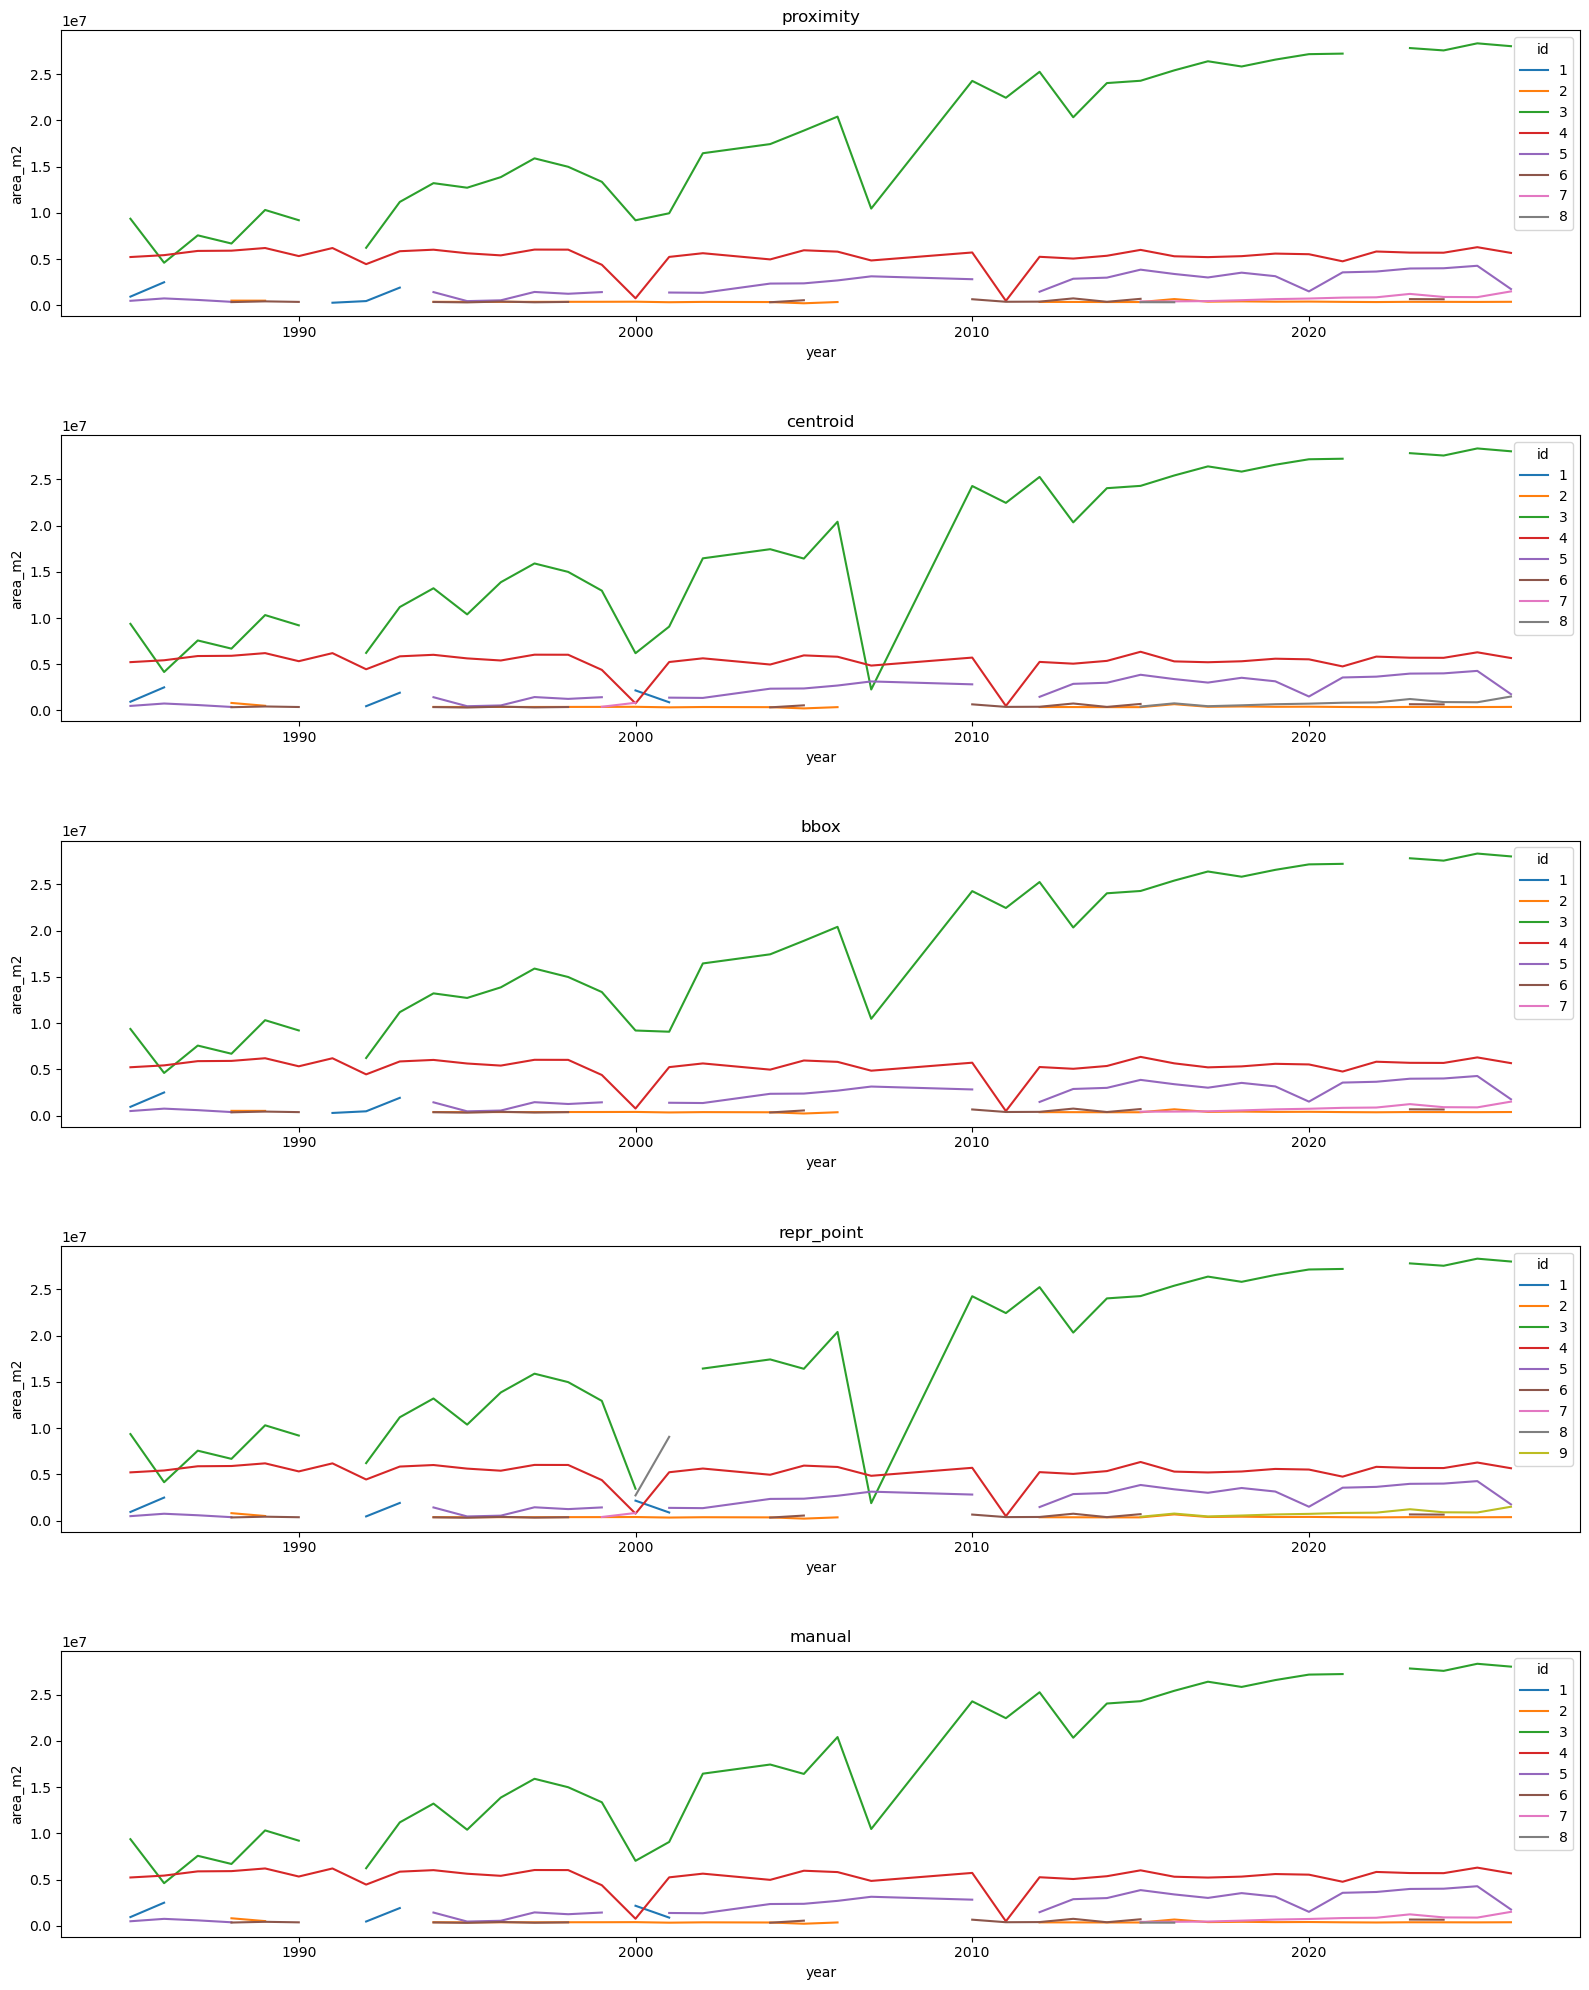

In [45]:
fig, axes = plt.subplots(len(vdcs), figsize=(16, 4 * len(vdcs)))

for row, (name, ds) in enumerate(vdcs.items()):

    ax_line = axes[row]
    ds["area_m2"].plot.line(
        x="year", hue="id", ax=ax_line,
        add_legend=True,
    )
    ax_line.set_title(f"{name}")
plt.tight_layout(h_pad=4)
plt.show()
plt.close()

Another way of representing the same data is with a heat map.

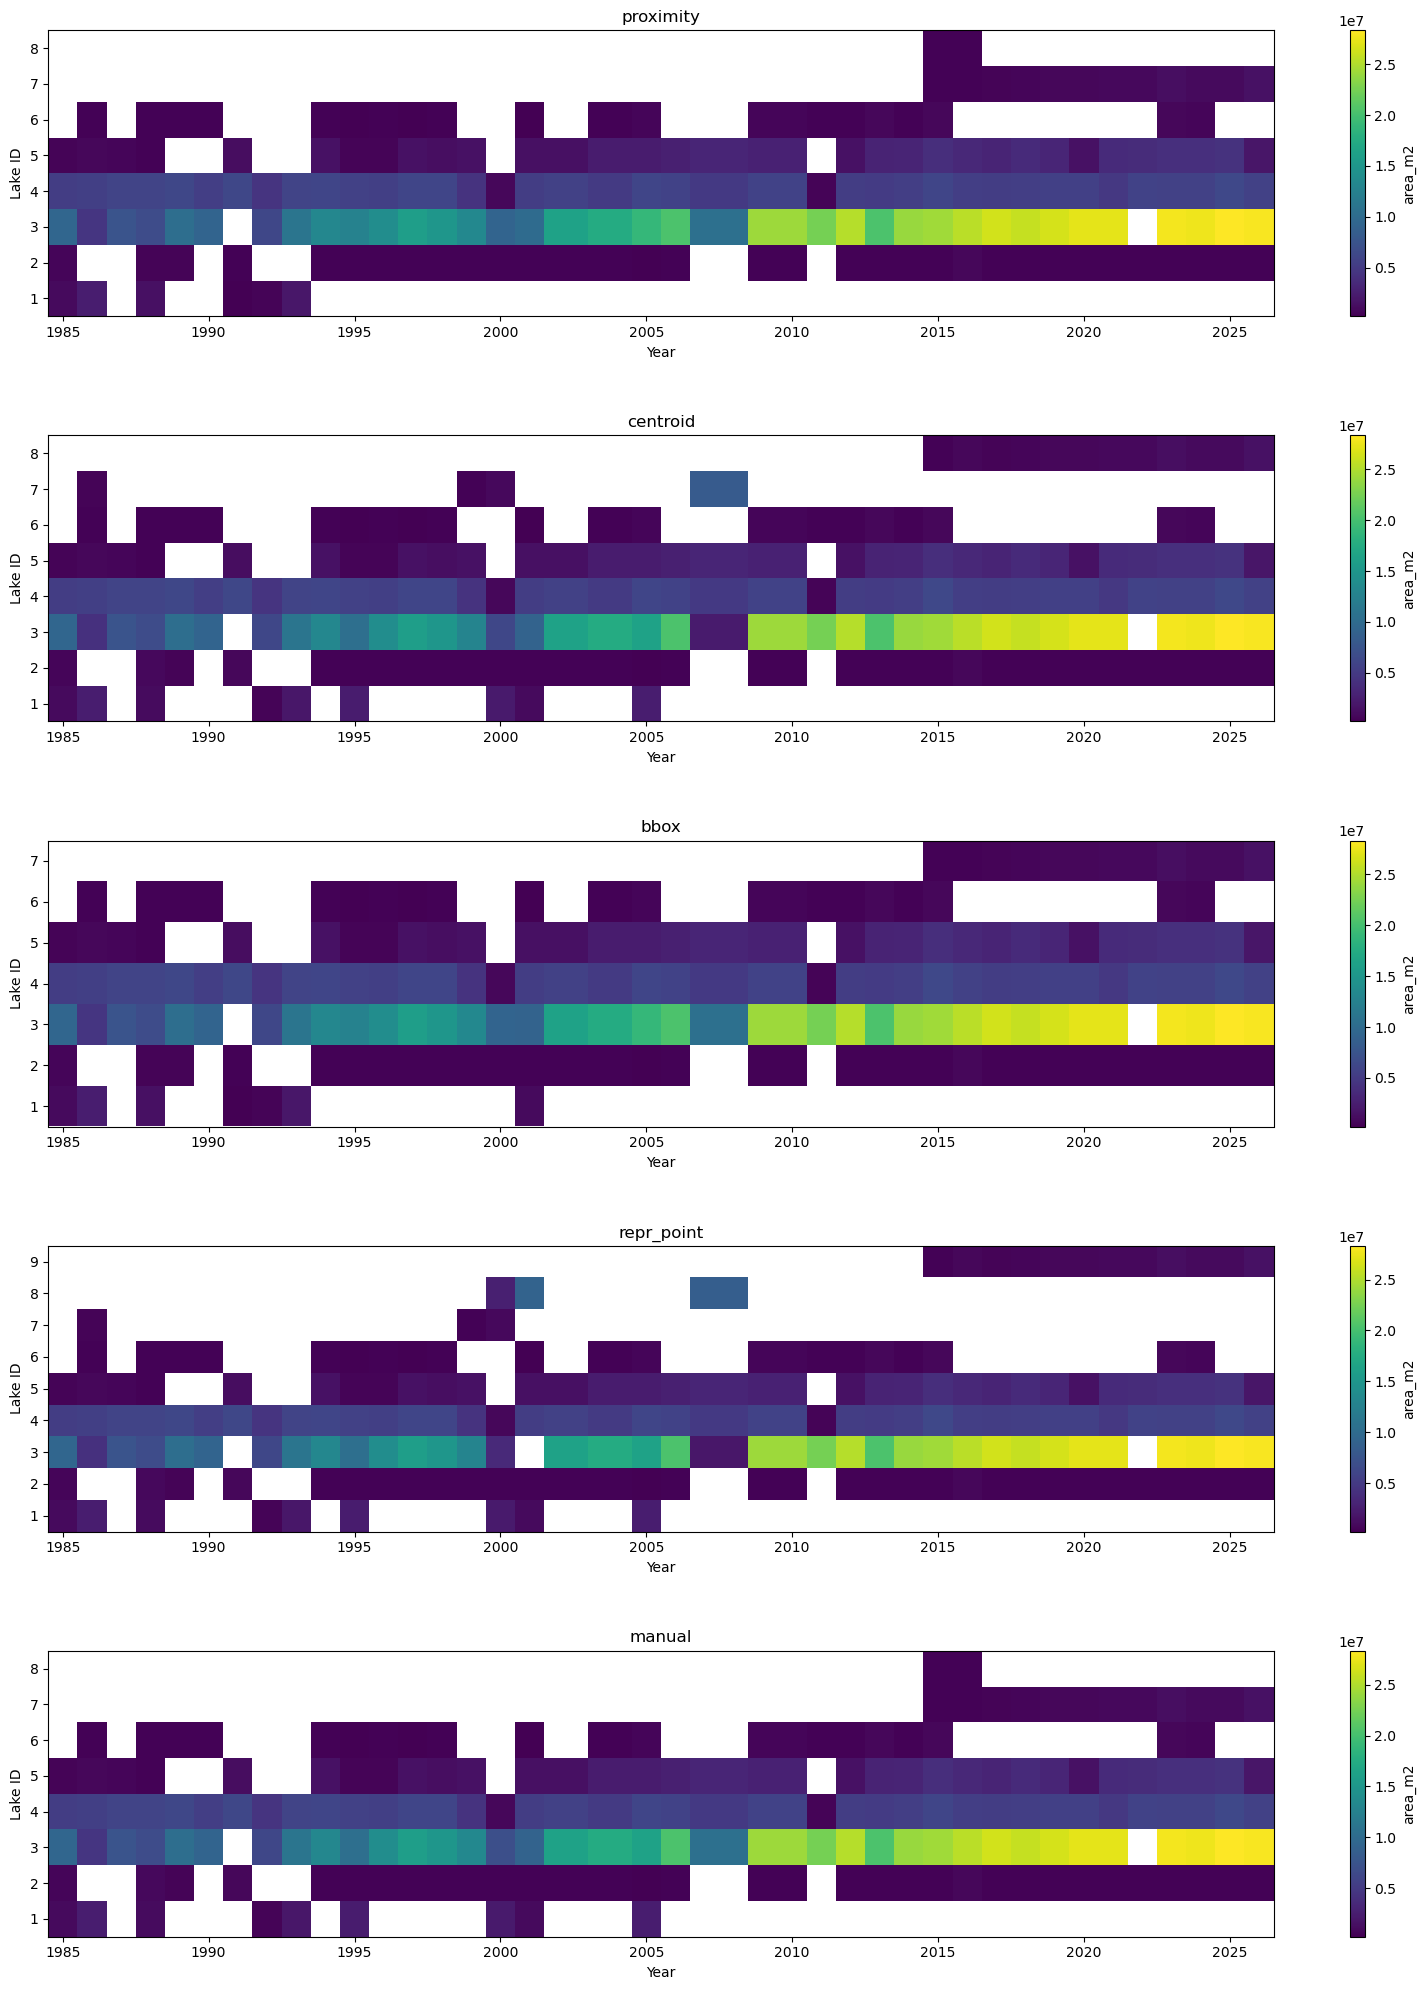

In [46]:
fig, axes = plt.subplots(len(vdcs), figsize=(16, 4 * len(vdcs)))

for row, (name, ds) in enumerate(vdcs.items()):
    ax_heat = axes[row]
    ds["area_m2"].plot(ax=ax_heat)
    ax_heat.set_title(f"{name}")
    ax_heat.set_xlabel("Year")
    ax_heat.set_ylabel("Lake ID")
plt.tight_layout(h_pad=4)
plt.show()
plt.close()

Heat map shows how Jökulsárlón and Fjallsárlón grow over the years. This could already help us in categorising lakes into stable, decreasing and increasing lakes.

Next we plot lake outlines per year to see their evolution and difference in grouping methods.

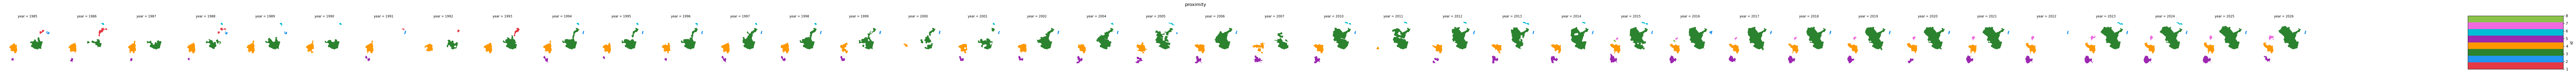

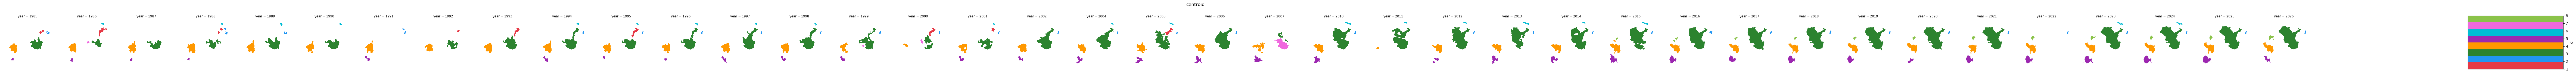

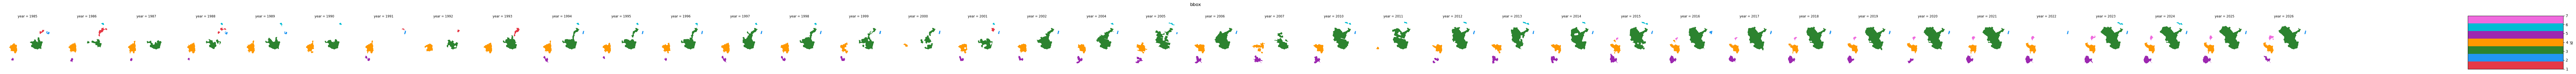

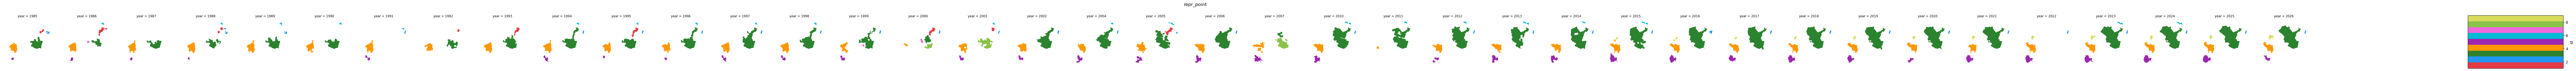

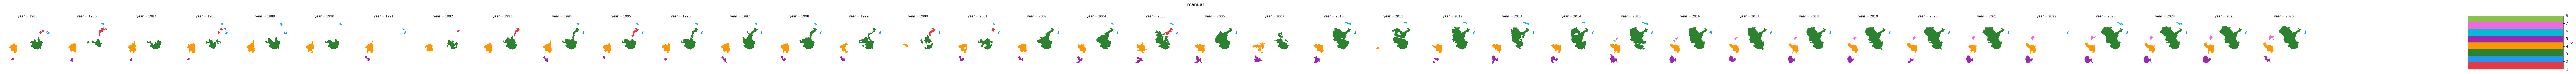

In [47]:
# ── build a fixed id → color mapping once ─────────────────────
all_ids = sorted(set(
    id_val
    for ds in vdcs.values()
    for id_val in ds["id"].values
))

distinct_colors = [
    "#E63946",  # red
    "#2196F3",  # blue
    "#2C832F",  # green
    "#FF9800",  # orange
    "#9C27B0",  # purple
    "#00BCD4",  # cyan
    "#F069DE",  # pink
    "#8BC34A",  # light green
    "#D9DB5C",  # lime
]
id_to_color = {
    id_val: distinct_colors[i % len(distinct_colors)]
    for i, id_val in enumerate(all_ids)
}

# ── plot ───────────────────────────────────────────────────────
for name, ds in vdcs.items():
    ids_in_ds = ds["id"].values
    cmap_for_ds = mcolors.ListedColormap([id_to_color[i] for i in ids_in_ds])

    fig, axes = ds.geometry.xvec.plot(
        col="year", hue="id",
        subplot_kws={"aspect": "equal"},
        cmap=cmap_for_ds,
    )
    for ax in axes.flat:
        ax.set_xlabel("")
        ax.set_ylabel("")
        ax.tick_params(left=False, bottom=False,
                       labelleft=False, labelbottom=False)
        ax.spines[["top", "right", "left", "bottom"]].set_visible(False)

    fig.suptitle(name, fontsize=12, y=1.02)
    plt.show()
    plt.close()

## 3 Compute summary geometries

 The `xvec`package allows for different aggregation functions for summarizing the geometry. Here we compute summary geometries using the following functions:
1. Bounding box of temporal union (default)
2. Centroid of temporal union
3. Temporal union
4. Collection of geometries
5. Oriented envelope
6. Convex hull
7. Concave hull

First, add a line to make it easier to change between grouping methods, if needed.

In [48]:
outlines_ds = outlines_ds_prox

### 3.1 Bounding box of temporal union
`envelope` is the default aggregation function of the `xvec` package. 

In [49]:
outlines_ds_env = outlines_ds.xvec.summarize_geometry(
    dim="id", geom_array="geometry")

outlines_ds_env

<xarray.Dataset> Size: 6kB
Dimensions:           (id: 8, year: 39)
Coordinates:
  * id                (id) int64 64B 1 2 3 4 5 6 7 8
    lake_name         (id) <U15 480B 'Jökulsárlón arm' ... 'Unnamed_2'
  * summary_geometry  (id) object 64B POLYGON ((734340 7114800, 737490 711480...
  * year              (year) int64 312B 1985 1986 1987 1988 ... 2024 2025 2026
  * spatial_ref       int64 8B 0
Data variables:
    geometry          (id, year) object 2kB POLYGON ((735450 7117050, 735450 ...
    area_m2           (id, year) float64 2kB 9.477e+05 2.501e+06 nan ... nan nan
Indexes:
    spatial_ref       CRSIndex (crs=EPSG:32627)
    summary_geometry  GeometryIndex (crs=EPSG:32627)

For querying, the summary_geometry needs to be a dimension itself (currently it is a coordinate hanging off `id`). 
We need to rebuild the VDC with a new structure.

In [50]:
# Extract values from ds
geoms       = outlines_ds_env["summary_geometry"].values   # shape (8,) — one union polygon per lake
geom_matrix = outlines_ds["geometry"].values               # shape (8, 38) — yearly polygons
area_matrix = outlines_ds["area_m2"].values                # shape (8, 38)
lake_ids    = outlines_ds["id"].values.tolist() 
lake_names  = outlines_ds["lake_name"].values.tolist()
year_list   = outlines_ds["year"].values.tolist()

# Rebuild with geometry as the dimension axis 
outlines_ds_env = xr.Dataset({
    "geometry": xr.DataArray(
        geom_matrix,
        dims=["summary_geometry", "year"],
        coords={"summary_geometry": geoms, "year": year_list},
    ),
    "area_m2": xr.DataArray(
        area_matrix,
        dims=["summary_geometry", "year"],
        coords={"summary_geometry": geoms, "year": year_list},
    ),
    "lake_id":   xr.DataArray(lake_ids,   dims=["summary_geometry"]),
    "lake_name": xr.DataArray(lake_names, dims=["summary_geometry"]),
}).xvec.set_geom_indexes("summary_geometry", crs=outlines_ds_env.xindexes["summary_geometry"].crs)

outlines_ds_env

<xarray.Dataset> Size: 6kB
Dimensions:           (summary_geometry: 8, year: 39)
Coordinates:
  * summary_geometry  (summary_geometry) object 64B POLYGON ((734340 7114800,...
  * year              (year) int64 312B 1985 1986 1987 1988 ... 2024 2025 2026
Data variables:
    geometry          (summary_geometry, year) object 2kB POLYGON ((735450 71...
    area_m2           (summary_geometry, year) float64 2kB 9.477e+05 ... nan
    lake_id           (summary_geometry) int64 64B 1 2 3 4 5 6 7 8
    lake_name         (summary_geometry) <U15 480B 'Jökulsárlón arm' ... 'Unn...
Indexes:
    summary_geometry  GeometryIndex (crs=EPSG:32627)

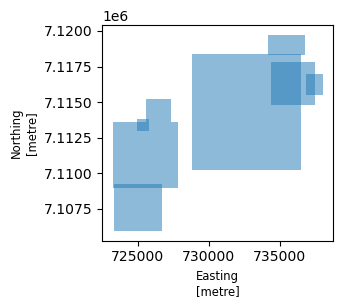

In [51]:
f, ax = outlines_ds_env.xvec.plot(geometry="summary_geometry", alpha=0.5)

### 3.2 Centroid of temporal union

In [52]:
outlines_ds_cent = outlines_ds.xvec.summarize_geometry(
    dim="id", geom_array="geometry", aggfunc="centroid")

outlines_ds_cent

<xarray.Dataset> Size: 6kB
Dimensions:           (id: 8, year: 39)
Coordinates:
  * id                (id) int64 64B 1 2 3 4 5 6 7 8
    lake_name         (id) <U15 480B 'Jökulsárlón arm' ... 'Unnamed_2'
  * summary_geometry  (id) object 64B POINT (735531.610964174 7116676.4282279...
  * year              (year) int64 312B 1985 1986 1987 1988 ... 2024 2025 2026
  * spatial_ref       int64 8B 0
Data variables:
    geometry          (id, year) object 2kB POLYGON ((735450 7117050, 735450 ...
    area_m2           (id, year) float64 2kB 9.477e+05 2.501e+06 nan ... nan nan
Indexes:
    spatial_ref       CRSIndex (crs=EPSG:32627)
    summary_geometry  GeometryIndex (crs=EPSG:32627)

In [53]:
# Extract values from ds
geoms = outlines_ds_cent["summary_geometry"].values   # shape (8,) — one union polygon per lake

# Rebuild with geometry as the dimension axis 
outlines_ds_cent = xr.Dataset({
    "geometry": xr.DataArray(
        geom_matrix,
        dims=["summary_geometry", "year"],
        coords={"summary_geometry": geoms, "year": year_list},
    ),
    "area_m2": xr.DataArray(
        area_matrix,
        dims=["summary_geometry", "year"],
        coords={"summary_geometry": geoms, "year": year_list},
    ),
    "lake_id":   xr.DataArray(lake_ids,   dims=["summary_geometry"]),
    "lake_name": xr.DataArray(lake_names, dims=["summary_geometry"]),
}).xvec.set_geom_indexes("summary_geometry", crs=outlines_ds_cent.xindexes["summary_geometry"].crs)

outlines_ds_cent

<xarray.Dataset> Size: 6kB
Dimensions:           (summary_geometry: 8, year: 39)
Coordinates:
  * summary_geometry  (summary_geometry) object 64B POINT (735531.610964174 7...
  * year              (year) int64 312B 1985 1986 1987 1988 ... 2024 2025 2026
Data variables:
    geometry          (summary_geometry, year) object 2kB POLYGON ((735450 71...
    area_m2           (summary_geometry, year) float64 2kB 9.477e+05 ... nan
    lake_id           (summary_geometry) int64 64B 1 2 3 4 5 6 7 8
    lake_name         (summary_geometry) <U15 480B 'Jökulsárlón arm' ... 'Unn...
Indexes:
    summary_geometry  GeometryIndex (crs=EPSG:32627)

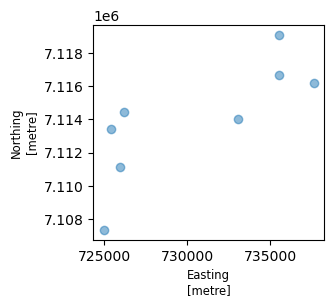

In [54]:
f, ax = outlines_ds_cent.xvec.plot(geometry="summary_geometry", alpha=0.5)

### 3.3 Temporal union

In [55]:
outlines_ds_union = outlines_ds.xvec.summarize_geometry(
    dim="id", geom_array="geometry", aggfunc="union")

outlines_ds_union

<xarray.Dataset> Size: 6kB
Dimensions:           (id: 8, year: 39)
Coordinates:
  * id                (id) int64 64B 1 2 3 4 5 6 7 8
    lake_name         (id) <U15 480B 'Jökulsárlón arm' ... 'Unnamed_2'
  * summary_geometry  (id) object 64B POLYGON ((735300 7116120, 735270 711612...
  * year              (year) int64 312B 1985 1986 1987 1988 ... 2024 2025 2026
  * spatial_ref       int64 8B 0
Data variables:
    geometry          (id, year) object 2kB POLYGON ((735450 7117050, 735450 ...
    area_m2           (id, year) float64 2kB 9.477e+05 2.501e+06 nan ... nan nan
Indexes:
    spatial_ref       CRSIndex (crs=EPSG:32627)
    summary_geometry  GeometryIndex (crs=EPSG:32627)

In [56]:
# Extract the pieces from ds
geoms = outlines_ds_union["summary_geometry"].values   # shape (8,) — one union polygon per lake

# Rebuild with geometry as the dimension axis 
outlines_ds_union = xr.Dataset({
    "geometry": xr.DataArray(
        geom_matrix,
        dims=["summary_geometry", "year"],
        coords={"summary_geometry": geoms, "year": year_list},
    ),
    "area_m2": xr.DataArray(
        area_matrix,
        dims=["summary_geometry", "year"],
        coords={"summary_geometry": geoms, "year": year_list},
    ),
    "lake_id":   xr.DataArray(lake_ids,   dims=["summary_geometry"]),
    "lake_name": xr.DataArray(lake_names, dims=["summary_geometry"]),
}).xvec.set_geom_indexes("summary_geometry", crs=outlines_ds_union.xindexes["summary_geometry"].crs)

outlines_ds_union

<xarray.Dataset> Size: 6kB
Dimensions:           (summary_geometry: 8, year: 39)
Coordinates:
  * summary_geometry  (summary_geometry) object 64B POLYGON ((735300 7116120,...
  * year              (year) int64 312B 1985 1986 1987 1988 ... 2024 2025 2026
Data variables:
    geometry          (summary_geometry, year) object 2kB POLYGON ((735450 71...
    area_m2           (summary_geometry, year) float64 2kB 9.477e+05 ... nan
    lake_id           (summary_geometry) int64 64B 1 2 3 4 5 6 7 8
    lake_name         (summary_geometry) <U15 480B 'Jökulsárlón arm' ... 'Unn...
Indexes:
    summary_geometry  GeometryIndex (crs=EPSG:32627)

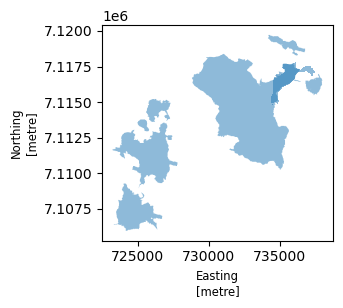

In [57]:
f, ax = outlines_ds_union.xvec.plot(geometry="summary_geometry", alpha=0.5)

### 3.4 Collection

In [58]:
outlines_ds_coll = outlines_ds.xvec.summarize_geometry(
    dim="id", geom_array="geometry", aggfunc="collection")

outlines_ds_coll

<xarray.Dataset> Size: 6kB
Dimensions:           (id: 8, year: 39)
Coordinates:
  * id                (id) int64 64B 1 2 3 4 5 6 7 8
    lake_name         (id) <U15 480B 'Jökulsárlón arm' ... 'Unnamed_2'
  * summary_geometry  (id) object 64B GEOMETRYCOLLECTION (POLYGON ((735450 71...
  * year              (year) int64 312B 1985 1986 1987 1988 ... 2024 2025 2026
  * spatial_ref       int64 8B 0
Data variables:
    geometry          (id, year) object 2kB POLYGON ((735450 7117050, 735450 ...
    area_m2           (id, year) float64 2kB 9.477e+05 2.501e+06 nan ... nan nan
Indexes:
    spatial_ref       CRSIndex (crs=EPSG:32627)
    summary_geometry  GeometryIndex (crs=EPSG:32627)

In [59]:
# Extract the pieces from ds
geoms = outlines_ds_coll["summary_geometry"].values   # shape (8,) — one union polygon per lake

# Rebuild with geometry as the dimension axis 
outlines_ds_coll = xr.Dataset({
    "geometry": xr.DataArray(
        geom_matrix,
        dims=["summary_geometry", "year"],
        coords={"summary_geometry": geoms, "year": year_list},
    ),
    "area_m2": xr.DataArray(
        area_matrix,
        dims=["summary_geometry", "year"],
        coords={"summary_geometry": geoms, "year": year_list},
    ),
    "lake_id":   xr.DataArray(lake_ids,   dims=["summary_geometry"]),
    "lake_name": xr.DataArray(lake_names, dims=["summary_geometry"]),
}).xvec.set_geom_indexes("summary_geometry", crs=outlines_ds_coll.xindexes["summary_geometry"].crs)

outlines_ds_coll

<xarray.Dataset> Size: 6kB
Dimensions:           (summary_geometry: 8, year: 39)
Coordinates:
  * summary_geometry  (summary_geometry) object 64B GEOMETRYCOLLECTION (POLYG...
  * year              (year) int64 312B 1985 1986 1987 1988 ... 2024 2025 2026
Data variables:
    geometry          (summary_geometry, year) object 2kB POLYGON ((735450 71...
    area_m2           (summary_geometry, year) float64 2kB 9.477e+05 ... nan
    lake_id           (summary_geometry) int64 64B 1 2 3 4 5 6 7 8
    lake_name         (summary_geometry) <U15 480B 'Jökulsárlón arm' ... 'Unn...
Indexes:
    summary_geometry  GeometryIndex (crs=EPSG:32627)

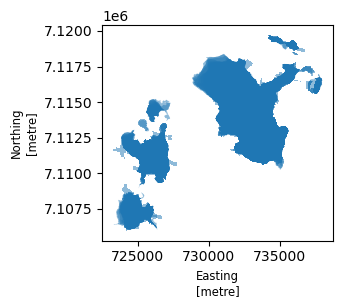

In [60]:
f, ax = outlines_ds_coll.xvec.plot(geometry="summary_geometry", alpha=0.5)

### 3.5 Oriented envelope

In [61]:
outlines_ds_orenv = outlines_ds.xvec.summarize_geometry(
    dim="id", geom_array="geometry", aggfunc="oriented_envelope")

outlines_ds_orenv

<xarray.Dataset> Size: 6kB
Dimensions:           (id: 8, year: 39)
Coordinates:
  * id                (id) int64 64B 1 2 3 4 5 6 7 8
    lake_name         (id) <U15 480B 'Jökulsárlón arm' ... 'Unnamed_2'
  * summary_geometry  (id) object 64B POLYGON ((737572.872032512 7117048.3743...
  * year              (year) int64 312B 1985 1986 1987 1988 ... 2024 2025 2026
  * spatial_ref       int64 8B 0
Data variables:
    geometry          (id, year) object 2kB POLYGON ((735450 7117050, 735450 ...
    area_m2           (id, year) float64 2kB 9.477e+05 2.501e+06 nan ... nan nan
Indexes:
    spatial_ref       CRSIndex (crs=EPSG:32627)
    summary_geometry  GeometryIndex (crs=EPSG:32627)

In [62]:
# Extract values from ds
geoms = outlines_ds_orenv["summary_geometry"].values   # shape (8,) — one union polygon per lake

# Rebuild with geometry as the dimension axis 
outlines_ds_orenv = xr.Dataset({
    "geometry": xr.DataArray(
        geom_matrix,
        dims=["summary_geometry", "year"],
        coords={"summary_geometry": geoms, "year": year_list},
    ),
    "area_m2": xr.DataArray(
        area_matrix,
        dims=["summary_geometry", "year"],
        coords={"summary_geometry": geoms, "year": year_list},
    ),
    "lake_id":   xr.DataArray(lake_ids,   dims=["summary_geometry"]),
    "lake_name": xr.DataArray(lake_names, dims=["summary_geometry"]),
}).xvec.set_geom_indexes("summary_geometry", crs=outlines_ds_orenv.xindexes["summary_geometry"].crs)

outlines_ds_orenv

<xarray.Dataset> Size: 6kB
Dimensions:           (summary_geometry: 8, year: 39)
Coordinates:
  * summary_geometry  (summary_geometry) object 64B POLYGON ((737572.87203251...
  * year              (year) int64 312B 1985 1986 1987 1988 ... 2024 2025 2026
Data variables:
    geometry          (summary_geometry, year) object 2kB POLYGON ((735450 71...
    area_m2           (summary_geometry, year) float64 2kB 9.477e+05 ... nan
    lake_id           (summary_geometry) int64 64B 1 2 3 4 5 6 7 8
    lake_name         (summary_geometry) <U15 480B 'Jökulsárlón arm' ... 'Unn...
Indexes:
    summary_geometry  GeometryIndex (crs=EPSG:32627)

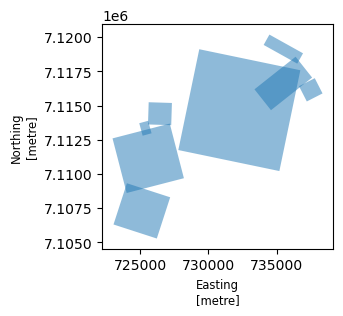

In [63]:
f, ax = outlines_ds_orenv.xvec.plot(geometry="summary_geometry", alpha=0.5)

### 3.6 Convex hull

In [64]:
outlines_ds_conv = outlines_ds.xvec.summarize_geometry(
    dim="id", geom_array="geometry", aggfunc="convex_hull")

outlines_ds_conv

<xarray.Dataset> Size: 6kB
Dimensions:           (id: 8, year: 39)
Coordinates:
  * id                (id) int64 64B 1 2 3 4 5 6 7 8
    lake_name         (id) <U15 480B 'Jökulsárlón arm' ... 'Unnamed_2'
  * summary_geometry  (id) object 64B POLYGON ((734460 7114800, 734400 711492...
  * year              (year) int64 312B 1985 1986 1987 1988 ... 2024 2025 2026
  * spatial_ref       int64 8B 0
Data variables:
    geometry          (id, year) object 2kB POLYGON ((735450 7117050, 735450 ...
    area_m2           (id, year) float64 2kB 9.477e+05 2.501e+06 nan ... nan nan
Indexes:
    spatial_ref       CRSIndex (crs=EPSG:32627)
    summary_geometry  GeometryIndex (crs=EPSG:32627)

In [65]:
# Extract values from ds
geoms = outlines_ds_conv["summary_geometry"].values   # shape (8,) — one union polygon per lake

# Rebuild with geometry as the dimension axis 
outlines_ds_conv = xr.Dataset({
    "geometry": xr.DataArray(
        geom_matrix,
        dims=["summary_geometry", "year"],
        coords={"summary_geometry": geoms, "year": year_list},
    ),
    "area_m2": xr.DataArray(
        area_matrix,
        dims=["summary_geometry", "year"],
        coords={"summary_geometry": geoms, "year": year_list},
    ),
    "lake_id":   xr.DataArray(lake_ids,   dims=["summary_geometry"]),
    "lake_name": xr.DataArray(lake_names, dims=["summary_geometry"]),
}).xvec.set_geom_indexes("summary_geometry", crs=outlines_ds_conv.xindexes["summary_geometry"].crs)

outlines_ds_conv

<xarray.Dataset> Size: 6kB
Dimensions:           (summary_geometry: 8, year: 39)
Coordinates:
  * summary_geometry  (summary_geometry) object 64B POLYGON ((734460 7114800,...
  * year              (year) int64 312B 1985 1986 1987 1988 ... 2024 2025 2026
Data variables:
    geometry          (summary_geometry, year) object 2kB POLYGON ((735450 71...
    area_m2           (summary_geometry, year) float64 2kB 9.477e+05 ... nan
    lake_id           (summary_geometry) int64 64B 1 2 3 4 5 6 7 8
    lake_name         (summary_geometry) <U15 480B 'Jökulsárlón arm' ... 'Unn...
Indexes:
    summary_geometry  GeometryIndex (crs=EPSG:32627)

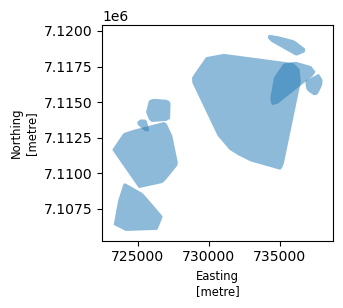

In [66]:
f, ax = outlines_ds_conv.xvec.plot(geometry="summary_geometry", alpha=0.5)

### 3.7 Concave hull

In [67]:
outlines_ds_conc = outlines_ds.xvec.summarize_geometry(
    dim="id", geom_array="geometry", aggfunc="concave_hull", ratio=0.2) # ratio of 0 is very tight, ratio of 1 is the same as convex_hull

outlines_ds_conc

<xarray.Dataset> Size: 6kB
Dimensions:           (id: 8, year: 39)
Coordinates:
  * id                (id) int64 64B 1 2 3 4 5 6 7 8
    lake_name         (id) <U15 480B 'Jökulsárlón arm' ... 'Unnamed_2'
  * summary_geometry  (id) object 64B POLYGON ((735180 7117470, 735210 711765...
  * year              (year) int64 312B 1985 1986 1987 1988 ... 2024 2025 2026
  * spatial_ref       int64 8B 0
Data variables:
    geometry          (id, year) object 2kB POLYGON ((735450 7117050, 735450 ...
    area_m2           (id, year) float64 2kB 9.477e+05 2.501e+06 nan ... nan nan
Indexes:
    spatial_ref       CRSIndex (crs=EPSG:32627)
    summary_geometry  GeometryIndex (crs=EPSG:32627)

In [68]:
# Extract values from ds
geoms = outlines_ds_conc["summary_geometry"].values   # shape (8,) — one union polygon per lake

# Rebuild with geometry as the dimension axis 
outlines_ds_conc = xr.Dataset({
    "geometry": xr.DataArray(
        geom_matrix,
        dims=["summary_geometry", "year"],
        coords={"summary_geometry": geoms, "year": year_list},
    ),
    "area_m2": xr.DataArray(
        area_matrix,
        dims=["summary_geometry", "year"],
        coords={"summary_geometry": geoms, "year": year_list},
    ),
    "lake_id":   xr.DataArray(lake_ids,   dims=["summary_geometry"]),
    "lake_name": xr.DataArray(lake_names, dims=["summary_geometry"]),
}).xvec.set_geom_indexes("summary_geometry", crs=outlines_ds_conc.xindexes["summary_geometry"].crs)

outlines_ds_conc

<xarray.Dataset> Size: 6kB
Dimensions:           (summary_geometry: 8, year: 39)
Coordinates:
  * summary_geometry  (summary_geometry) object 64B POLYGON ((735180 7117470,...
  * year              (year) int64 312B 1985 1986 1987 1988 ... 2024 2025 2026
Data variables:
    geometry          (summary_geometry, year) object 2kB POLYGON ((735450 71...
    area_m2           (summary_geometry, year) float64 2kB 9.477e+05 ... nan
    lake_id           (summary_geometry) int64 64B 1 2 3 4 5 6 7 8
    lake_name         (summary_geometry) <U15 480B 'Jökulsárlón arm' ... 'Unn...
Indexes:
    summary_geometry  GeometryIndex (crs=EPSG:32627)

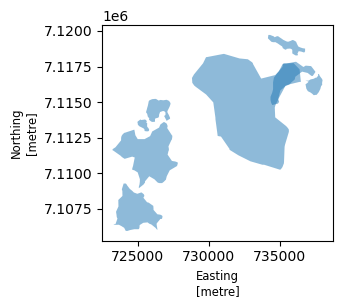

In [69]:
f, ax = outlines_ds_conc.xvec.plot(geometry="summary_geometry", alpha=0.5)

## 4 Comparing the different summary geometry methods
Here we use xvec.query() to compare the which summary geometry function is the most applicable for our case study.

### 4.1 To which lake does this point belong to?

In [70]:
query_point = Point(732788, 7112440)

datasets = {
    "envelope":   outlines_ds_env,
    "centroid":  outlines_ds_cent,
    "union": outlines_ds_union,
    "collection":  outlines_ds_coll,
    "oriented envelope": outlines_ds_orenv,
    "convex hull": outlines_ds_conv,
    "concave hull": outlines_ds_conc,
}

for name, ds in datasets.items():
    result = ds.xvec.query("summary_geometry", query_point)
    if result.sizes["summary_geometry"] == 0:
        print(f"{name:10s}: no match")
    else:
        print(f"{name:10s}: {result['lake_name'].values.tolist()}")

envelope  : ['Jökulsárlón']
centroid  : no match
union     : ['Jökulsárlón']
collection: ['Jökulsárlón']
oriented envelope: ['Jökulsárlón']
convex hull: ['Jökulsárlón']
concave hull: ['Jökulsárlón']


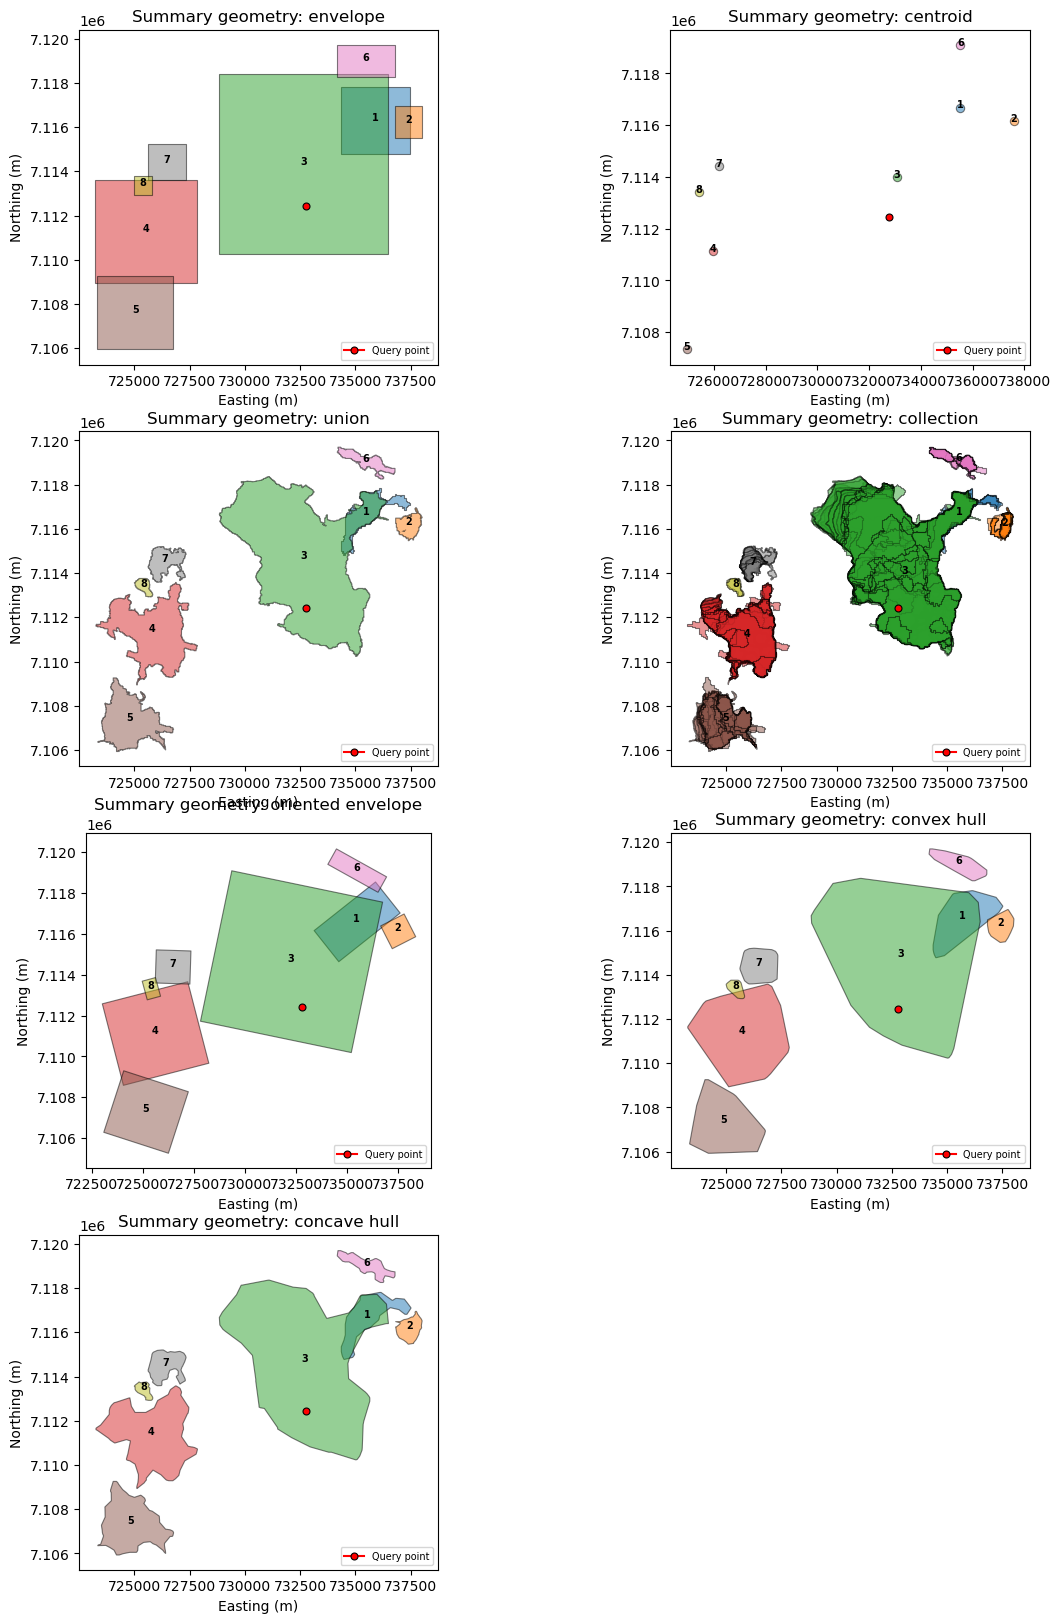

In [71]:
# Function to extract a flat GeoDataFrame of (id, summary_geometry)
def summary_gdf(ds):
    """Return a GeoDataFrame with columns ['id', 'geometry'] from a summarised VDC."""
    geoms = ds["summary_geometry"].values          # numpy array of Shapely geometries
    ids   = ds["lake_id"].values                        # numpy array of lake IDs
    return gpd.GeoDataFrame({"lake_id": ids, "geometry": geoms}, crs="EPSG:32627")

# Plot all summary geometries 
fig, axes = plt.subplots(4, 2, figsize=(14, 20))
axes = axes.flatten()

cmap = plt.cm.tab10
lake_ids_sorted = sorted(outlines_ds_env["lake_id"].values)
norm = mcolors.Normalize(vmin=0, vmax=len(lake_ids_sorted))

for ax, (name, ds) in zip(axes, datasets.items()):
    gdf = summary_gdf(ds)
    for j, lid in enumerate(lake_ids_sorted):
        row = gdf[gdf["lake_id"] == lid]
        if not row.empty and row.iloc[0].geometry is not None:
            row.plot(ax=ax, color=cmap(norm(j)), alpha=0.5,
                     edgecolor="k", linewidth=0.8)
            centroid = row.iloc[0].geometry.centroid
            ax.annotate(str(lid), (centroid.x, centroid.y),
                        fontsize=7, ha="center", fontweight="bold")

    # Query point
    ax.plot(query_point.x, query_point.y,
            marker=".", markersize=10, color="red",
            markeredgecolor="black", markeredgewidth=0.8,
            label="Query point")

    ax.set_title(f"Summary geometry: {name}")
    ax.set_xlabel("Easting (m)")
    ax.set_ylabel("Northing (m)")
    ax.legend(fontsize=7, loc="lower right")
    axes[-1].set_visible(False)
    
plt.show()
plt.close()

### 4.2 Which lakes intersect with this polygon?

Query with a bounding box 


Possible predicate options:  ``` 'covered_by', 'within', 'contains_properly', 'touches', 'overlaps', 'crosses', 'contains', 'covers', 'intersects' ```

In [72]:
query_polygon = box(728018, 7111762, 731242, 7109828)  

for name, ds in datasets.items():
    result = ds.xvec.query("summary_geometry", query_polygon, predicate="intersects")
    if result.sizes["summary_geometry"] == 0:
        print(f"{name:10s}: no match")
    else:
        print(f"{name:10s}: {result['lake_id'].values.tolist()}")

envelope  : [3]
centroid  : no match
union     : no match
collection: no match
oriented envelope: [4, 3]
convex hull: no match
concave hull: no match


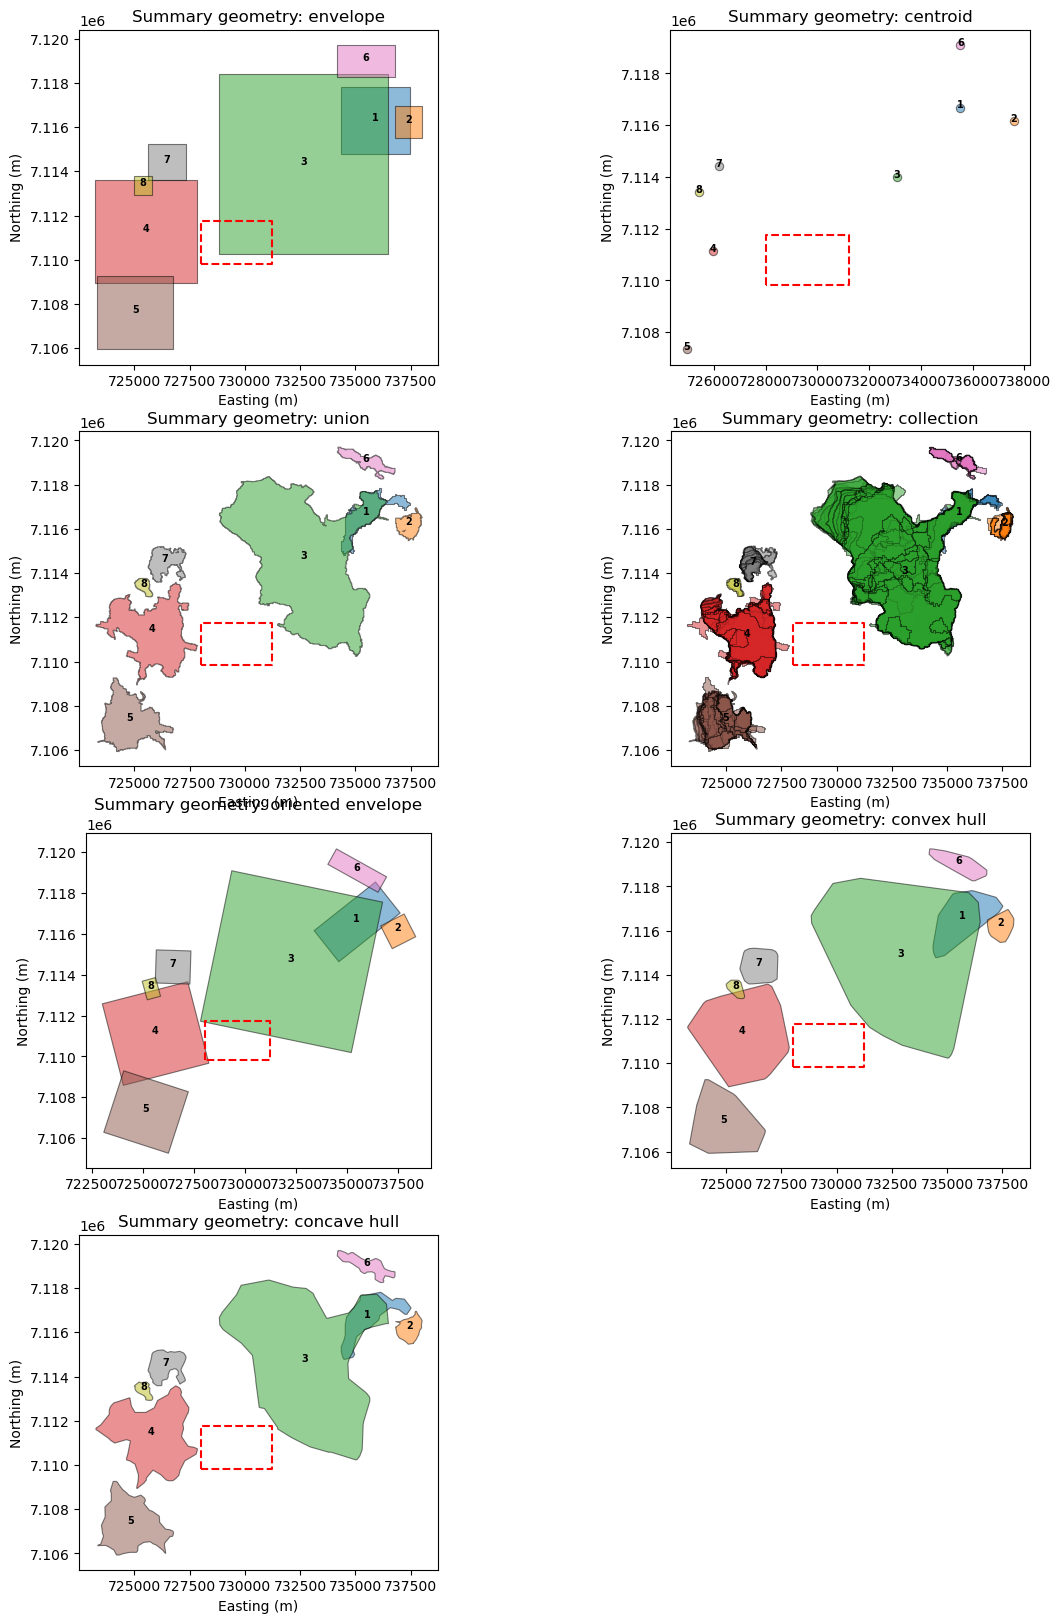

In [73]:
fig, axes = plt.subplots(4, 2, figsize=(14, 20))
axes = axes.flatten()

cmap = plt.cm.tab10
lake_ids_sorted = sorted(outlines_ds_env["lake_id"].values)
norm = mcolors.Normalize(vmin=0, vmax=len(lake_ids_sorted))

for ax, (name, ds) in zip(axes, datasets.items()):
    gdf = summary_gdf(ds)

    for j, lid in enumerate(lake_ids_sorted):
        row = gdf[gdf["lake_id"] == lid]
        if not row.empty and row.iloc[0].geometry is not None:
            row.plot(ax=ax, color=cmap(norm(j)), alpha=0.5,
                     edgecolor="k", linewidth=0.8)
            centroid = row.iloc[0].geometry.centroid
            ax.annotate(str(lid), (centroid.x, centroid.y),
                        fontsize=7, ha="center", fontweight="bold")

    # Query polygon 
    gpd.GeoSeries([query_polygon], crs="EPSG:32627").plot(
        ax=ax, facecolor="none", edgecolor="red",
        linewidth=1.5, linestyle="--",
    )

    ax.set_title(f"Summary geometry: {name}")
    ax.set_xlabel("Easting (m)")
    ax.set_ylabel("Northing (m)")

axes[-1].set_visible(False)

plt.show()
plt.close()

### 4.3 What is the nearest lake to the point?

In [74]:
query_point = Point(728247, 7113730)

for name, ds in datasets.items():
    result = ds.sel(summary_geometry=query_point, method="nearest")
    print(f"{name:20s}: {result['lake_name'].values.tolist()}")

envelope            : ['Breiðárlón']
centroid            : ['Unnamed_1']
union               : ['Unnamed_1']
collection          : ['Unnamed_1']
oriented envelope   : ['Jökulsárlón']
convex hull         : ['Unnamed_1']
concave hull        : ['Unnamed_1']


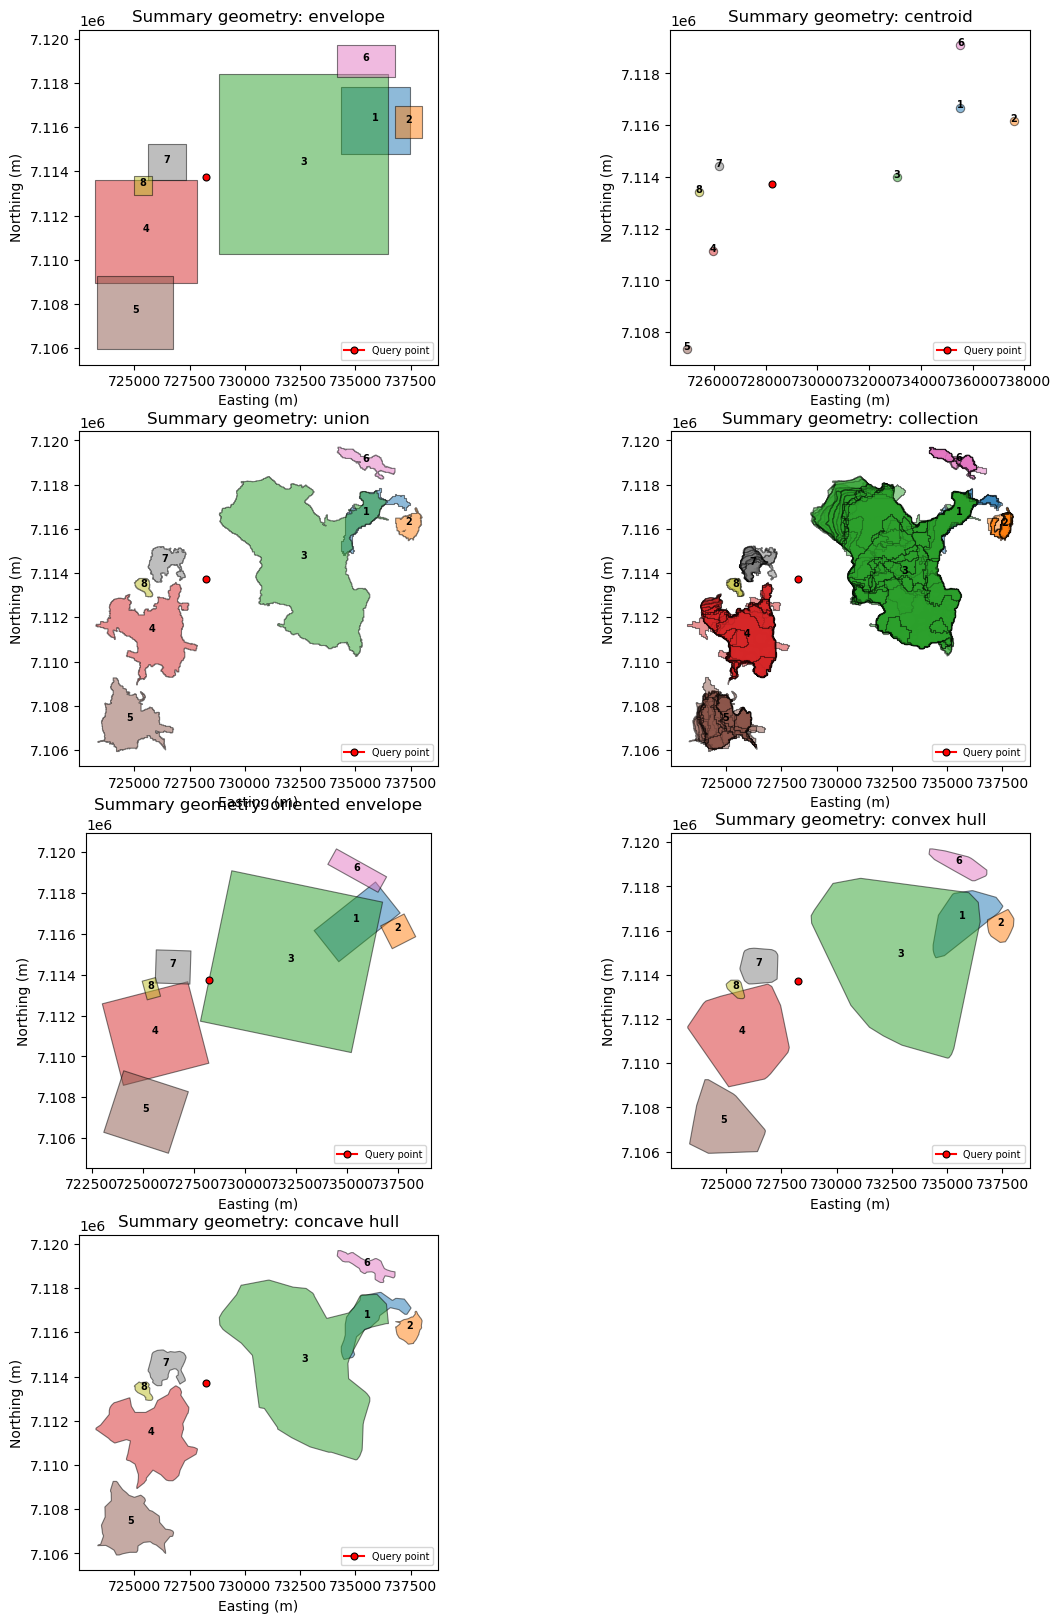

In [75]:
# Plot all summary geometries 
fig, axes = plt.subplots(4, 2, figsize=(14, 20))
axes = axes.flatten()

cmap = plt.cm.tab10
lake_ids_sorted = sorted(outlines_ds_env["lake_id"].values)
norm = mcolors.Normalize(vmin=0, vmax=len(lake_ids_sorted))

for ax, (name, ds) in zip(axes, datasets.items()):
    gdf = summary_gdf(ds)
    for j, lid in enumerate(lake_ids_sorted):
        row = gdf[gdf["lake_id"] == lid]
        if not row.empty and row.iloc[0].geometry is not None:
            row.plot(ax=ax, color=cmap(norm(j)), alpha=0.5,
                     edgecolor="k", linewidth=0.8)
            centroid = row.iloc[0].geometry.centroid
            ax.annotate(str(lid), (centroid.x, centroid.y),
                        fontsize=7, ha="center", fontweight="bold")

    # Query point
    ax.plot(query_point.x, query_point.y,
            marker=".", markersize=10, color="red",
            markeredgecolor="black", markeredgewidth=0.8,
            label="Query point")

    ax.set_title(f"Summary geometry: {name}")
    ax.set_xlabel("Easting (m)")
    ax.set_ylabel("Northing (m)")
    ax.legend(fontsize=7, loc="lower right")
    axes[-1].set_visible(False)
    
plt.show()
plt.close()

## 5. Save the VDC Dataset

Geometry variables are stored as WKT before writing to NetCDF (xarray cannot serialise Shapely objects natively).

In [76]:
def save_vdc_to_netcdf(ds: xr.Dataset, out_path: Path) -> None:
    """
    Save a VDC xr.Dataset to NetCDF by converting geometries to WKT strings.
    Works directly from the output of make_vdc().
    """
    # geometry variable to WKT 
    geom_array = ds["geometry"].values          # numpy object array of Shapely geoms
    wkt_geoms  = np.vectorize(
        lambda g: to_wkt(g) if g is not None else ""
    )(geom_array)

    # summary_geometry coordinate to WKT 
    wkt_summary = np.array([
        to_wkt(g) if g is not None else ""
        for g in ds["summary_geometry"].values
    ]) if "summary_geometry" in ds.coords else None

    # build a plain xr.Dataset (no geometry types)
    coords = {
        "id":        ds["lake_id"].values,
        "year":      ds["year"].values,
        "lake_name": ("id", ds["lake_name"].values),
    }

    data_vars = {
        "geometry_wkt": xr.DataArray(
            wkt_geoms,
            dims=["id", "year"],
            attrs={"description": "Shapely geometry serialised as WKT"},
        ),
        "area_m2": xr.DataArray(
            ds["area_m2"].values,
            dims=["id", "year"],
        ),
    }

    if wkt_summary is not None:
        data_vars["summary_geometry_wkt"] = xr.DataArray(
            wkt_summary,
            dims=["id"],
            attrs={"description": "Summary geometry serialised as WKT"},
        )

    ds_nc = xr.Dataset(data_vars, coords=coords)
    ds_nc.attrs["crs"]         = str(ds.proj.crs) if hasattr(ds, "proj") else "EPSG:32627"
    ds_nc.attrs["description"] = "Glacial lake VDC — geometries stored as WKT strings"

    out_path = Path(out_path)
    out_path.parent.mkdir(parents=True, exist_ok=True)
    ds_nc.to_netcdf(out_path)
    print("Saved")


# Save a selected VDC
save_vdc_to_netcdf(
    outlines_ds_union,
    OUT_DIR / "glacial_lakes_vdc_union.nc",
)

# Or save all VDCs at once
#for name, ds in vdcs.items():
#    save_vdc_to_netcdf(ds, OUT_DIR / f"glacial_lakes_vdc_{name}.nc")

Saved
